# Análisis de reseñas de hoteles de lujo en Europa (Booking.com)

## Objetivo general
Explorar, limpiar y extraer valor del conjunto de datos de 515.000 reseñas de 1.493 hoteles europeos, aplicando técnicas de NLP, regresión, clustering y visualización.

## Fuente de datos
- **Origen**: Booking.com (datos públicos extraídos por terceros)
- **Atribución**: Propiedad intelectual de Booking.com, uso académico/educativo.
- **Filas**: ~515.000 reseñas
- **Columnas**: 17 (dirección, fechas, puntuaciones, reseñas texto, nacionalidad, coordenadas, etc.)

## Plan de trabajo

### 1. ETL (Extracción, Transformación y Carga)
### 2. EDA (Análisis Exploratorio de Datos)
#### 2.1. Análisis de sentimiento en reseñas
#### 2.2. Regresión de palabras clave sobre la puntuación
#### 2.3. Correlación nacionalidad ↔ puntuación
#### 2.4. Visualizaciones informativas y atractivas
#### 2.5. Clustering de hoteles basado en opiniones
#### 2.6. Motor de recomendación simple por característica especial


# 1) Cargar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 2) Importar funciones

In [2]:
def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        print("¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        print(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        print((df.isnull().sum() / len(df) * 100).round(2))

        print("¿Cuántas filas duplicadas hay?")
        print(df.duplicated().sum())
        

    print('#' * 90)

In [3]:
def detectar_outliers(df, columnas=None, metodo='iqr', factor_iqr=1.5, 
                      mostrar_histogramas=False, mostrar_tabla=True):
    """
    Detecta outliers en columnas numéricas.
    
    Parámetros:
    - df: DataFrame
    - columnas: lista específica (si None, usa todas las numéricas)
    - metodo: 'iqr' o 'zscore'
    - factor_iqr: para IQR (1.5 típico, 3 para extremos)
    - mostrar_histogramas: bool, muestra distribución
    - mostrar_tabla: bool, muestra resumen
    
    Retorna:
    - dict con info de outliers por columna
    """
    if columnas is None:
        columnas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        # Excluir coordenadas y fechas numéricas si existen
        columnas = [col for col in columnas if col not in ['lat', 'lng', 'days_since_review']]
    
    resultados = {}
    
    for col in columnas:
        datos = df[col].dropna()
        if len(datos) == 0:
            continue
            
        if metodo == 'iqr':
            Q1 = datos.quantile(0.25)
            Q3 = datos.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - factor_iqr * IQR
            upper_bound = Q3 + factor_iqr * IQR
            outliers = datos[(datos < lower_bound) | (datos > upper_bound)]
        elif metodo == 'zscore':
            from scipy import stats
            z_scores = np.abs(stats.zscore(datos))
            outliers = datos[z_scores > 3]
        
        resultados[col] = {
            'total_outliers': len(outliers),
            'porcentaje': (len(outliers) / len(datos)) * 100,
            'limite_inferior': lower_bound if metodo == 'iqr' else None,
            'limite_superior': upper_bound if metodo == 'iqr' else None,
            'valores_extremos': outliers.tolist()[:10],  # top 10
            'min': datos.min(),
            'max': datos.max(),
            'media': datos.mean(),
            'mediana': datos.median()
        }
        
        if mostrar_histogramas:
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            ax[0].hist(datos, bins=50, edgecolor='black', alpha=0.7)
            ax[0].axvline(lower_bound, color='r', linestyle='--', label=f'Límite inferior: {lower_bound:.2f}')
            ax[0].axvline(upper_bound, color='r', linestyle='--', label=f'Límite superior: {upper_bound:.2f}')
            ax[0].set_title(f'Distribución de {col}')
            ax[0].legend()
            
            # Boxplot
            ax[1].boxplot(datos, vert=True)
            ax[1].set_title(f'Boxplot de {col}')
            plt.tight_layout()
            plt.show()
    
    if mostrar_tabla:
        print("\n" + "="*90)
        print("RESUMEN DE OUTLIERS DETECTADOS")
        print("="*90)
        for col, info in resultados.items():
            print(f"\n📊 {col}:")
            print(f"   • Outliers: {info['total_outliers']:,} ({info['porcentaje']:.2f}%)")
            print(f"   • Rango normal: [{info['limite_inferior']:.2f}, {info['limite_superior']:.2f}]")
            print(f"   • Valores reales: min={info['min']:.2f}, max={info['max']:.2f}, media={info['media']:.2f}, mediana={info['mediana']:.2f}")
            if info['valores_extremos']:
                print(f"   • Ejemplos extremos: {info['valores_extremos'][:5]}")
    
    return resultados

In [4]:
def analizar_outliers_contextuales(df):
    """
    Analiza outliers específicos del contexto de hoteles.
    """
    print("🔍 ANÁLISIS CONTEXTUAL DE OUTLIERS EN REVIEWS DE HOTELES\n")
    
    # 1. Puntuaciones extremas pero válidas
    print("1. PUNTUACIONES EXTREMAS (≤3 o ≥9):")
    puntuaciones_bajas = df[df['Reviewer_Score'] <= 3].shape[0]
    puntuaciones_altas = df[df['Reviewer_Score'] >= 9].shape[0]
    print(f"   • Puntuaciones ≤3: {puntuaciones_bajas:,} ({puntuaciones_bajas/len(df)*100:.2f}%) - Críticas muy negativas")
    print(f"   • Puntuaciones ≥9: {puntuaciones_altas:,} ({puntuaciones_altas/len(df)*100:.2f}%) - Experiencias excelentes")
    
    # 2. Hoteles con volumen anormal de reseñas
    print("\n2. VOLUMEN DE RESEÑAS POR HOTEL:")
    reviews_por_hotel = df.groupby('Hotel_Name')['Total_Number_of_Reviews'].first()
    print(f"   • Mediana: {reviews_por_hotel.median():,.0f} reseñas/hotel")
    print(f"   • Top 1% más populares: ≥ {reviews_por_hotel.quantile(0.99):,.0f} reseñas")
    print(f"   • Bottom 1% menos reseñados: ≤ {reviews_por_hotel.quantile(0.01):,.0f} reseñas")
    
    # 3. Reseñas sin texto (solo puntuación)
    print("\n3. RESEÑAS SIN TEXTO REAL:")
    sin_positiva = df[df['Positive_Review'] == 'Sin positiva'].shape[0]
    sin_negativa = df[df['Negative_Review'] == 'Sin negativa'].shape[0]
    print(f"   • Sin reseña positiva: {sin_positiva:,} ({sin_positiva/len(df)*100:.2f}%)")
    print(f"   • Sin reseña negativa: {sin_negativa:,} ({sin_negativa/len(df)*100:.2f}%)")
    
    # 4. Conteo de palabras atípico
    print("\n4. LONGITUD EXTREMA DE RESEÑAS:")
    for tipo in ['Positive', 'Negative']:
        col_counts = f'Review_Total_{tipo}_Word_Counts'
        cuartil_99 = df[col_counts].quantile(0.99)
        print(f"   • {tipo}: 99% de reseñas tienen ≤ {cuartil_99:.0f} palabras")
        print(f"     Máximo: {df[col_counts].max():.0f} palabras (solo {df[df[col_counts] > cuartil_99].shape[0]} reseñas)")
    
    return None

# 3) Cargar Dataset

In [5]:
df = pd.read_csv(r"C:\Users\andy_\Documents\Datasets\Hotel Review Booking\booking_reviews.csv")
df.head(5)

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [6]:
# PASO 1: Exploración inicial (ya la tienes)
exploracion_inicial(df)

# PASO 2: Análisis contextual (más útil para entender los datos)
analizar_outliers_contextuales(df)

# PASO 3: Detección técnica de outliers (solo si necesitas números exactos)
# Pero con factor_iqr = 3 (más permisivo para datos de hoteles)
resultados_outliers = detectar_outliers(df, metodo='iqr', factor_iqr=3, 
                                        mostrar_histogramas=False, 
                                        mostrar_tabla=True)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 515,738 filas y 17 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


¿Cuáles son las últimas cinco filas del conjunto de datos?


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,2,8,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,11,12,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,0,3,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,25,3,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677
515737,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/9/2015,8.1,Atlantis Hotel Vienna,Hungary,I was in 3rd floor It didn t work Free Wife,13,2823,staff was very kind,6,1,8.3,"[' Leisure trip ', ' Family with young childre...",725 day,48.203745,16.335677


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
160885,354 Queenstown Road Battersea London SW8 4AE U...,568,2/23/2016,8.6,Pestana Chelsea Bridge Hotel Spa,United Kingdom,Having to pour our own champagne New bar staf...,35,1686,We love it here Amazing value for money Staff...,17,3,10.0,"[' Leisure trip ', ' Couple ', ' Deluxe King R...",527 day,51.481600,-0.148105
129351,277 Carrer de Proven a Eixample 08037 Barcelon...,47,2/4/2017,9.4,The One Barcelona GL,United Kingdom,Booking com pictures of the hotel as doesn t ...,13,332,Everything This hotel is amazing central loca...,35,9,10.0,"[' Leisure trip ', ' Couple ', ' Double or Twi...",180 day,41.396145,2.163167
180937,40 trinity square City of London London EC3N 4...,832,1/29/2017,9.1,citizenM Tower of London,Nigeria,No Negative,0,4672,Very new very clean With the location right n...,46,1,9.6,"[' Business trip ', ' Solo traveler ', ' Doubl...",186 day,51.510237,-0.076443
423046,Provincialeweg 38 Zuidoost 1108 AB Amsterdam N...,245,5/14/2017,7.5,Golden Tulip Amsterdam Riverside,Australia,No Negative,0,2362,Reception staff were very friendly and very h...,90,16,9.2,"[' Leisure trip ', ' Couple ', ' Standard Twin...",81 days,52.315453,4.996300
325931,Galleria Del Corso 3 Milan City Center 20122 M...,141,10/22/2016,7.8,IH Hotels Milano Ambasciatori,United Kingdom,The only way to travel between floors was in ...,40,2387,The rooms are very nice and big too And the h...,29,2,10.0,"[' Leisure trip ', ' Group ', ' Twin Room ', '...",285 day,45.464435,9.195273


¿Cuáles son las columnas del conjunto de datos?
	- Hotel_Address
	- Additional_Number_of_Scoring
	- Review_Date
	- Average_Score
	- Hotel_Name
	- Reviewer_Nationality
	- Negative_Review
	- Review_Total_Negative_Word_Counts
	- Total_Number_of_Reviews
	- Positive_Review
	- Review_Total_Positive_Word_Counts
	- Total_Number_of_Reviews_Reviewer_Has_Given
	- Reviewer_Score
	- Tags
	- days_since_review
	- lat
	- lng
¿Cuál es el tipo de datos de cada columna?
Hotel_Address                                     str
Additional_Number_of_Scoring                    int64
Review_Date                                       str
Average_Score                                 float64
Hotel_Name                                        str
Reviewer_Nationality                              str
Negative_Review                                   str
Review_Total_Negative_Word_Counts               int64
Total_Number_of_Reviews                         int64
Positive_Review                                   str
Revi

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
count,515738,515738.0,515738,515738.0,515738,515738,515738,515738.0,515738.0,515738,515738.0,515738.0,515738.0,515738,515738,512470.0,512470.0
unique,1493,,731,,1492,227,330011,,,412601,,,,55242,731,,
top,163 Marsh Wall Docklands Tower Hamlets London ...,,8/2/2017,,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,,,No Positive,,,,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days,,
freq,4789,,2585,,4789,245246,127890,,,35946,,,,5101,2585,,
mean,,498.081836,,8.397487,,,,18.53945,2743.743944,,17.776458,7.166001,8.395077,,,49.442439,2.823803
std,,500.538467,,0.548048,,,,29.690831,2317.464868,,21.804185,11.040228,1.637856,,,3.466325,4.579425
min,,1.0,,5.2,,,,0.0,43.0,,0.0,1.0,2.5,,,41.328376,-0.369758
25%,,169.0,,8.1,,,,2.0,1161.0,,5.0,1.0,7.5,,,48.214662,-0.143372
50%,,341.0,,8.4,,,,9.0,2134.0,,11.0,3.0,8.8,,,51.499981,0.010607
75%,,660.0,,8.8,,,,23.0,3613.0,,22.0,8.0,9.6,,,51.516288,4.834443


¿Hay valores nulos en el conjunto de datos?
Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64
¿Cuál es la proporción de valores nulos en cada columna?
Hotel_Address      

# 4) ETL

In [7]:
# 1. Eliminar duplicados
df = df.drop_duplicates()
print(f"Duplicados eliminados. Nuevo tamaño: {len(df):,} filas")

# 2. Limpiar coordenadas nulas (opciones: eliminar o imputar)
# Como son pocos (0.63%), los eliminamos
df_limpio = df.dropna(subset=['lat', 'lng'])
print(f"Filas con coordenadas: {len(df_limpio):,}")

# 3. Convertir days_since_review a numérico (está como str)
df_limpio['days_since_review'] = pd.to_numeric(df_limpio['days_since_review'], errors='coerce')

# 4. Convertir Review_Date a datetime
df_limpio['Review_Date'] = pd.to_datetime(df_limpio['Review_Date'])

# 5. Crear variable de estación para análisis temporal
def get_season(month):
    if month in [12, 1, 2]: return 'Invierno'
    elif month in [3, 4, 5]: return 'Primavera'
    elif month in [6, 7, 8]: return 'Verano'
    else: return 'Otoño'

df_limpio['Season'] = df_limpio['Review_Date'].dt.month.map(get_season)

# 6. Limpiar texto (reemplazar "Sin positiva/negativa" por NaN o cadena vacía)
df_limpio['Positive_Review_Clean'] = df_limpio['Positive_Review'].replace('Sin positiva', '')
df_limpio['Negative_Review_Clean'] = df_limpio['Negative_Review'].replace('Sin negativa', '')

# 7. Verificar resultado
print(f"\n✅ Dataset limpio: {len(df_limpio):,} filas, {len(df_limpio.columns)} columnas")

Duplicados eliminados. Nuevo tamaño: 515,212 filas
Filas con coordenadas: 511,944

✅ Dataset limpio: 511,944 filas, 20 columnas


In [8]:
df.head(1)

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968


### 4.1) Vamos a extraer el País de la columna Hotel_Address

In [9]:
# Función para extraer país de la dirección
def extraer_pais(direccion):
    """
    Extrae el país de la dirección del hotel.
    Basado en palabras clave y capitales europeas.
    """
    if pd.isna(direccion):
        return 'Desconocido'
    
    direccion_str = str(direccion)
    
    # 1. Buscar palabras país al final (separadas por espacio)
    paises_conocidos = {
        'Spain': 'España',
        'France': 'Francia', 
        'Italy': 'Italia',
        'Germany': 'Alemania',
        'United Kingdom': 'Reino Unido',
        'UK': 'Reino Unido',
        'England': 'Reino Unido',
        'Netherlands': 'Países Bajos',
        'Austria': 'Austria',
        'Switzerland': 'Suiza',
        'Portugal': 'Portugal',
        'Greece': 'Grecia',
        'Turkey': 'Turquía',
        'Croatia': 'Croacia',
        'Hungary': 'Hungría',
        'Czech Republic': 'República Checa',
        'Poland': 'Polonia',
        'Denmark': 'Dinamarca',
        'Sweden': 'Suecia',
        'Norway': 'Noruega',
        'Finland': 'Finlandia',
        'Ireland': 'Irlanda',
        'Belgium': 'Bélgica'
    }
    
    # Buscar coincidencias
    for key, value in paises_conocidos.items():
        if key.lower() in direccion_str.lower():
            return value
    
    # 2. Identificar por ciudades principales
    ciudades_pais = {
        'London': 'Reino Unido',
        'Paris': 'Francia',
        'Rome': 'Italia',
        'Barcelona': 'España',
        'Madrid': 'España',
        'Berlin': 'Alemania',
        'Munich': 'Alemania',
        'Amsterdam': 'Países Bajos',
        'Vienna': 'Austria',
        'Zurich': 'Suiza',
        'Lisbon': 'Portugal',
        'Athens': 'Grecia',
        'Istanbul': 'Turquía'
    }
    
    for city, pais in ciudades_pais.items():
        if city.lower() in direccion_str.lower():
            return pais
    
    return 'Otro'

# Aplicar la extracción
df_limpio['Hotel_Country'] = df_limpio['Hotel_Address'].apply(extraer_pais)

# Verificar resultados
print("Distribución de países:")
print(df_limpio['Hotel_Country'].value_counts())
print(f"\nEjemplos de direcciones y países extraídos:")
for addr in df_limpio['Hotel_Address'].sample(5):
    print(f"  {addr[:60]}... → {extraer_pais(addr)}")

Distribución de países:
Hotel_Country
Reino Unido     262298
España           59942
Francia          59031
Países Bajos     57211
Italia           37204
Austria          36258
Name: count, dtype: int64

Ejemplos de direcciones y países extraídos:
  29 31 Gower Street Camden London WC1E 6HG United Kingdom... → Reino Unido
  37 Nottingham Place Westminster Borough London W1U 5LT Unite... → Reino Unido
  130 135 Minories City of London London EC3N 1NU United Kingd... → Reino Unido
  Paseo Garc a Faria 37 47 Sant Mart 08019 Barcelona Spain... → España
  97 Cromwell Road Kensington and Chelsea London SW7 4DN Unite... → Reino Unido


### 4.2) Extraer Ciudades de la columna de Hotel_Address

In [10]:
# 1. Extraer ciudad también (útil para análisis local)
def extraer_ciudad(direccion):
    """Extrae ciudad de la dirección (aproximación)"""
    if pd.isna(direccion):
        return 'Desconocido'
    
    # Patrones comunes
    partes = str(direccion).split()
    
    # Buscar palabras que parecen ciudades (capitalizadas y no muy largas)
    posibles_ciudades = ['London', 'Paris', 'Rome', 'Barcelona', 'Madrid', 
                         'Berlin', 'Munich', 'Amsterdam', 'Vienna', 'Zurich',
                         'Lisbon', 'Athens', 'Istanbul', 'Prague', 'Budapest']
    
    for ciudad in posibles_ciudades:
        if ciudad.lower() in str(direccion).lower():
            return ciudad
    
    return 'Otra'

df_limpio['Hotel_City'] = df_limpio['Hotel_Address'].apply(extraer_ciudad)

# 2. Procesar Tags (vienen como lista anidada)
# Ejemplo: "[('Desayuno incluido', 'Gratis'), ('Wifi', 'Gratis')]"
import ast

def procesar_tags(tag_str):
    """Convierte tags en lista de características"""
    if pd.isna(tag_str) or tag_str == '':
        return []
    try:
        # Intentar evaluar como lista de tuples
        tags_list = ast.literal_eval(tag_str)
        if isinstance(tags_list, list):
            # Extraer solo los nombres de las características
            return [tag[0] for tag in tags_list if isinstance(tag, tuple)]
    except:
        pass
    return []

df_limpio['Tags_List'] = df_limpio['Tags'].apply(procesar_tags)

# 3. Crear columna de mes y año
df_limpio['Review_Year'] = df_limpio['Review_Date'].dt.year
df_limpio['Review_Month'] = df_limpio['Review_Date'].dt.month
df_limpio['Review_DayOfWeek'] = df_limpio['Review_Date'].dt.dayofweek

# 4. Combinar reseñas para análisis de sentimiento
df_limpio['Full_Review'] = df_limpio['Positive_Review_Clean'] + ' ' + df_limpio['Negative_Review_Clean']
df_limpio['Full_Review'] = df_limpio['Full_Review'].str.strip()

# 5. Calcular longitud real de texto (no solo conteo de palabras dado)
df_limpio['Review_Length_Chars'] = df_limpio['Full_Review'].str.len()

# 6. Crear categoría de puntuación
def score_category(score):
    if score >= 9:
        return 'Excelente'
    elif score >= 8:
        return 'Muy Bueno'
    elif score >= 6:
        return 'Bueno'
    elif score >= 4:
        return 'Regular'
    else:
        return 'Malo'

df_limpio['Score_Category'] = df_limpio['Reviewer_Score'].apply(score_category)

# 7. Verificar todo
print("\n✅ ETL completado. Nuevas columnas:")
nuevas_columnas = ['Hotel_Country', 'Hotel_City', 'Tags_List', 'Review_Year', 
                   'Review_Month', 'Review_DayOfWeek', 'Full_Review', 
                   'Score_Category', 'Review_Length_Chars']
for col in nuevas_columnas:
    print(f"  • {col}: {df_limpio[col].dtype}")

# 8. Guardar checkpoint (opcional)
# df_limpio.to_parquet('booking_hotels_clean.parquet', index=False)


✅ ETL completado. Nuevas columnas:
  • Hotel_Country: str
  • Hotel_City: str
  • Tags_List: object
  • Review_Year: int32
  • Review_Month: int32
  • Review_DayOfWeek: int32
  • Full_Review: str
  • Score_Category: str
  • Review_Length_Chars: int64


In [11]:
# Diccionario más completo de ciudades europeas
def extraer_ciudad_mejorado(direccion):
    """Extrae ciudad de la dirección con diccionario más completo"""
    if pd.isna(direccion):
        return 'Desconocido'
    
    direccion_str = str(direccion)
    
    # Diccionario completo de ciudades europeas
    ciudades_dict = {
        # Reino Unido
        'London': 'Londres', 'Manchester': 'Mánchester', 'Birmingham': 'Birmingham',
        'Edinburgh': 'Edimburgo', 'Glasgow': 'Glasgow', 'Liverpool': 'Liverpool',
        
        # España
        'Barcelona': 'Barcelona', 'Madrid': 'Madrid', 'Seville': 'Sevilla',
        'Valencia': 'Valencia', 'Malaga': 'Málaga', 'Marbella': 'Marbella',
        
        # Francia
        'Paris': 'París', 'Nice': 'Niza', 'Lyon': 'Lyon', 'Marseille': 'Marsella',
        'Bordeaux': 'Burdeos', 'Cannes': 'Cannes',
        
        # Países Bajos
        'Amsterdam': 'Ámsterdam', 'Rotterdam': 'Róterdam', 'The Hague': 'La Haya',
        'Utrecht': 'Utrecht',
        
        # Italia
        'Rome': 'Roma', 'Venice': 'Venecia', 'Florence': 'Florencia', 
        'Milan': 'Milán', 'Naples': 'Nápoles', 'Turin': 'Turín',
        'Bologna': 'Bolonia', 'Verona': 'Verona',
        
        # Austria
        'Vienna': 'Viena', 'Salzburg': 'Salzburgo', 'Innsbruck': 'Innsbruck',
        'Graz': 'Graz', 'Linz': 'Linz',
        
        # Alemania (por si aparecen)
        'Berlin': 'Berlín', 'Munich': 'Múnich', 'Hamburg': 'Hamburgo',
        'Frankfurt': 'Fráncfort', 'Cologne': 'Colonia',
        
        # Suiza
        'Zurich': 'Zúrich', 'Geneva': 'Ginebra', 'Bern': 'Berna',
        
        # Portugal
        'Lisbon': 'Lisboa', 'Porto': 'Oporto',
        
        # Grecia
        'Athens': 'Atenas', 'Santorini': 'Santorini',
        
        # Turquía
        'Istanbul': 'Estambul', 'Antalya': 'Antalya'
    }
    
    # Buscar coincidencias
    for key, value in ciudades_dict.items():
        if key.lower() in direccion_str.lower():
            return value
    
    # Si no encuentra, extraer última palabra (puede ser país)
    palabras = direccion_str.split()
    if palabras:
        ultima = palabras[-1]
        if len(ultima) > 3 and ultima[0].isupper():
            return f"Otra ({ultima[:15]})"
    
    return 'Otra ciudad'

# Aplicar mejora
df_limpio['Hotel_City_Improved'] = df_limpio['Hotel_Address'].apply(extraer_ciudad_mejorado)

print("🏨 TOP 15 CIUDADES MEJORADAS:")
print(df_limpio['Hotel_City_Improved'].value_counts().head(15))

🏨 TOP 15 CIUDADES MEJORADAS:
Hotel_City_Improved
Londres      262298
Barcelona     59942
París         59031
Ámsterdam     57211
Milán         37204
Viena         36258
Name: count, dtype: int64


In [12]:
# Estadísticas por ciudad (VERSIÓN CORREGIDA)
ciudades_stats = df_limpio.groupby('Hotel_City').agg({
    'Reviewer_Score': ['mean', 'count', 'std'],
    'Hotel_Name': 'nunique'
}).round(2)

# Renombrar columnas correctamente
ciudades_stats.columns = ['Puntuación_Media', 'N_Reseñas', 'Desv_Puntuación', 'N_Hoteles']

# Resetear índice para evitar errores
ciudades_stats = ciudades_stats.reset_index()

# Ordenar por número de reseñas
ciudades_stats = ciudades_stats.sort_values('N_Reseñas', ascending=False)

print("\n📊 CIUDADES CON MÁS RESEÑAS:")
print(ciudades_stats.head(10))

print("\n⭐ CIUDADES MEJOR PUNTUADAS (mínimo 1000 reseñas):")
ciudades_filtradas = ciudades_stats[ciudades_stats['N_Reseñas'] >= 1000].sort_values('Puntuación_Media', ascending=False)
print(ciudades_filtradas.head(10))

print("\n⚠️ CIUDADES PEOR PUNTUADAS (mínimo 1000 reseñas):")
print(ciudades_filtradas.tail(10))


📊 CIUDADES CON MÁS RESEÑAS:
  Hotel_City  Puntuación_Media  N_Reseñas  Desv_Puntuación  N_Hoteles
2     London              8.32     262298             1.67        400
1  Barcelona              8.55      59942             1.55        208
4      Paris              8.42      59031             1.65        455
0  Amsterdam              8.46      57211             1.60        105
3       Otra              8.35      37204             1.65        162
5     Vienna              8.57      36258             1.50        147

⭐ CIUDADES MEJOR PUNTUADAS (mínimo 1000 reseñas):
  Hotel_City  Puntuación_Media  N_Reseñas  Desv_Puntuación  N_Hoteles
5     Vienna              8.57      36258             1.50        147
1  Barcelona              8.55      59942             1.55        208
0  Amsterdam              8.46      57211             1.60        105
4      Paris              8.42      59031             1.65        455
3       Otra              8.35      37204             1.65        162
2     Lond

# 5) EDA

### 5.1) Análisis Exploratorio Básico

📊 EDA - ANÁLISIS EXPLORATORIO DE DATOS

1️⃣ DISTRIBUCIÓN DE REVIEWER_SCORE
--------------------------------------------------


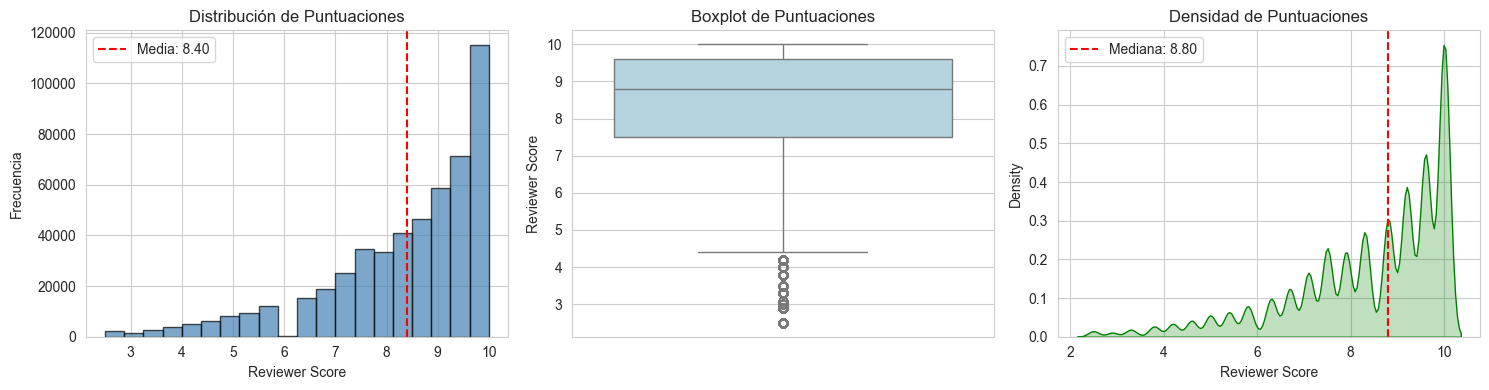

Estadísticas descriptivas de Reviewer_Score:
  • Media: 8.40
  • Mediana: 8.80
  • Moda: 10.00
  • Desviación estándar: 1.64
  • Rango: 2.5 - 10.0

2️⃣ ANÁLISIS TEMPORAL DE RESEÑAS
--------------------------------------------------


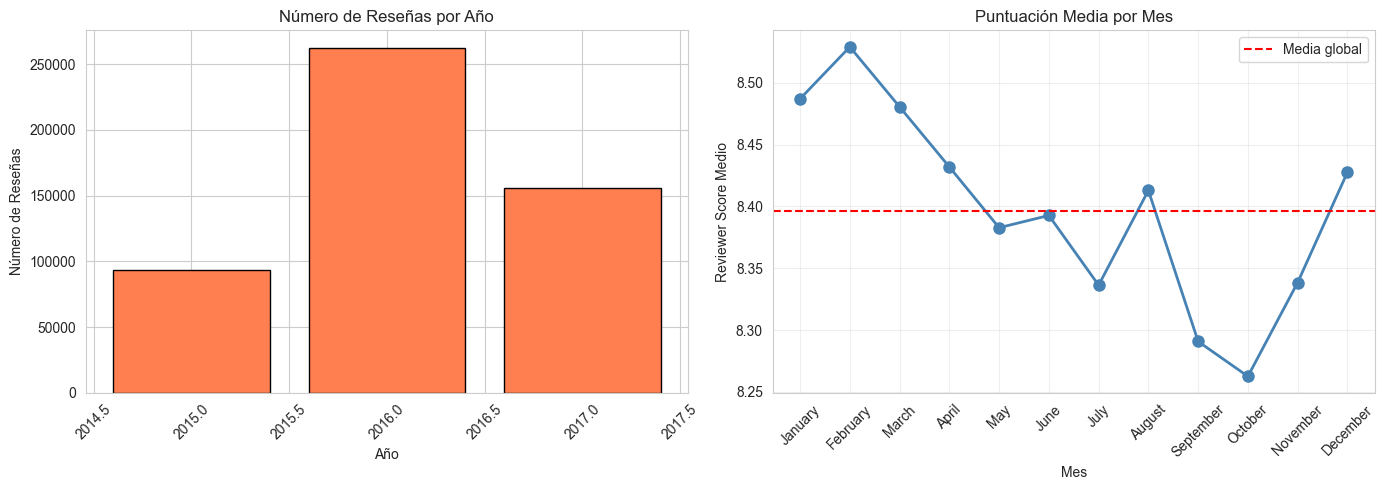

Años con datos: 2015 - 2017
Año con más reseñas: 2016 (262,473 reseñas)
Mes con mejor puntuación: February (8.53)
Mes con peor puntuación: October (8.26)

3️⃣ MATRIZ DE CORRELACIÓN
--------------------------------------------------


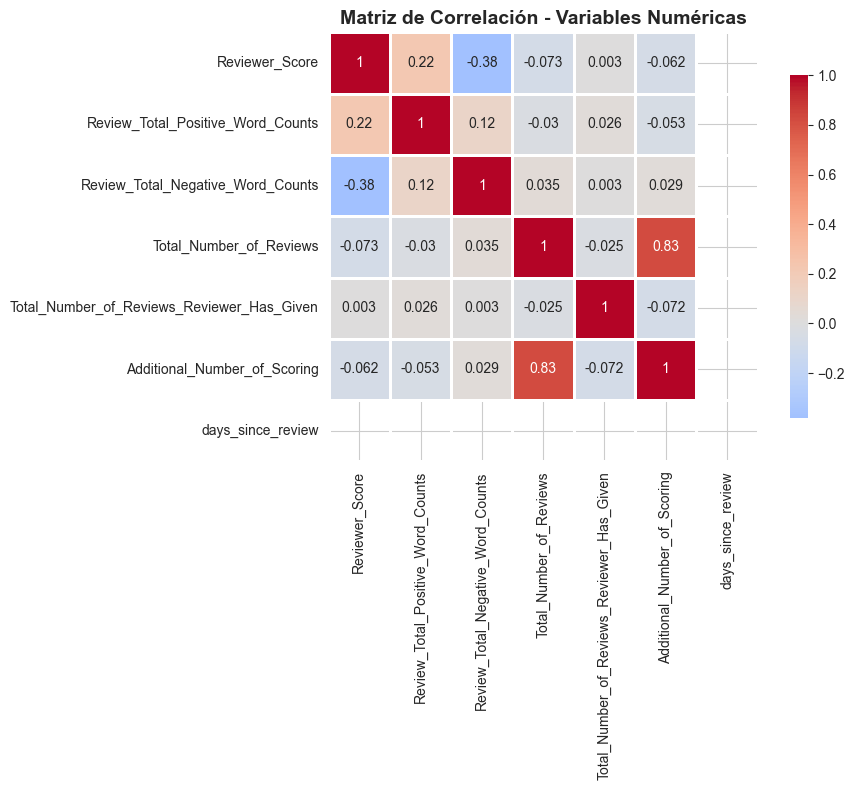


Correlaciones más fuertes con Reviewer_Score:
  • Review_Total_Positive_Word_Counts: 0.221
  • Total_Number_of_Reviews_Reviewer_Has_Given: 0.003
  • Additional_Number_of_Scoring: -0.062
  • Total_Number_of_Reviews: -0.073
  • Review_Total_Negative_Word_Counts: -0.383
  • days_since_review: nan


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("📊 EDA - ANÁLISIS EXPLORATORIO DE DATOS")
print("="*80)

# 1. DISTRIBUCIÓN DE PUNTUACIONES
print("\n1️⃣ DISTRIBUCIÓN DE REVIEWER_SCORE")
print("-"*50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df_limpio['Reviewer_Score'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribución de Puntuaciones')
axes[0].set_xlabel('Reviewer Score')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', label=f'Media: {df_limpio["Reviewer_Score"].mean():.2f}')
axes[0].legend()

# Boxplot
sns.boxplot(y=df_limpio['Reviewer_Score'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot de Puntuaciones')
axes[1].set_ylabel('Reviewer Score')

# Density plot
sns.kdeplot(df_limpio['Reviewer_Score'], ax=axes[2], fill=True, color='green')
axes[2].set_title('Densidad de Puntuaciones')
axes[2].set_xlabel('Reviewer Score')
axes[2].axvline(df_limpio['Reviewer_Score'].median(), color='red', linestyle='--', label=f'Mediana: {df_limpio["Reviewer_Score"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Estadísticas descriptivas de Reviewer_Score:")
print(f"  • Media: {df_limpio['Reviewer_Score'].mean():.2f}")
print(f"  • Mediana: {df_limpio['Reviewer_Score'].median():.2f}")
print(f"  • Moda: {df_limpio['Reviewer_Score'].mode()[0]:.2f}")
print(f"  • Desviación estándar: {df_limpio['Reviewer_Score'].std():.2f}")
print(f"  • Rango: {df_limpio['Reviewer_Score'].min():.1f} - {df_limpio['Reviewer_Score'].max():.1f}")

# 2. ANÁLISIS TEMPORAL
print("\n2️⃣ ANÁLISIS TEMPORAL DE RESEÑAS")
print("-"*50)

# Agregar año y mes si no lo tienes
if 'Review_Year' not in df_limpio.columns:
    df_limpio['Review_Date'] = pd.to_datetime(df_limpio['Review_Date'])
    df_limpio['Review_Year'] = df_limpio['Review_Date'].dt.year
    df_limpio['Review_Month'] = df_limpio['Review_Date'].dt.month

# Reseñas por año
reseñas_por_año = df_limpio['Review_Year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por año
axes[0].bar(reseñas_por_año.index, reseñas_por_año.values, color='coral', edgecolor='black')
axes[0].set_title('Número de Reseñas por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de Reseñas')
axes[0].tick_params(axis='x', rotation=45)

# Puntuación media por mes (todos los años combinados)
df_limpio['Review_Month_Name'] = df_limpio['Review_Date'].dt.month_name()
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
score_por_mes = df_limpio.groupby('Review_Month_Name')['Reviewer_Score'].mean().reindex(orden_meses)

axes[1].plot(range(12), score_por_mes.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[1].set_title('Puntuación Media por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Reviewer Score Medio')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(orden_meses, rotation=45)
axes[1].axhline(y=df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', label='Media global')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Años con datos: {reseñas_por_año.index.min()} - {reseñas_por_año.index.max()}")
print(f"Año con más reseñas: {reseñas_por_año.idxmax()} ({reseñas_por_año.max():,} reseñas)")
print(f"Mes con mejor puntuación: {score_por_mes.idxmax()} ({score_por_mes.max():.2f})")
print(f"Mes con peor puntuación: {score_por_mes.idxmin()} ({score_por_mes.min():.2f})")

# 3. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
print("\n3️⃣ MATRIZ DE CORRELACIÓN")
print("-"*50)

# Seleccionar variables numéricas relevantes
variables_numericas = ['Reviewer_Score', 'Review_Total_Positive_Word_Counts', 
                       'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
                       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Additional_Number_of_Scoring',
                       'days_since_review']

# Convertir days_since_review a numérico si es necesario
if df_limpio['days_since_review'].dtype == 'object':
    df_limpio['days_since_review'] = pd.to_numeric(df_limpio['days_since_review'], errors='coerce')

corr_matrix = df_limpio[variables_numericas].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelaciones más fuertes con Reviewer_Score:")
corr_con_score = corr_matrix['Reviewer_Score'].sort_values(ascending=False)
for var, corr in corr_con_score.items():
    if var != 'Reviewer_Score':
        print(f"  • {var}: {corr:.3f}")

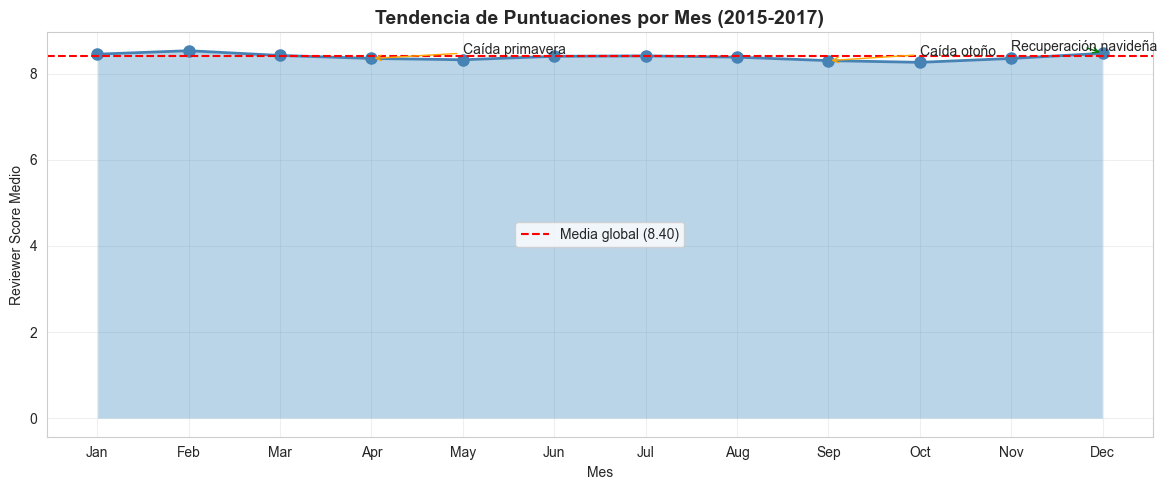


📊 INTERPRETACIÓN DE LA ESTACIONALIDAD:
• Febrero (8.53): ¿Vacaciones de invierno? ¿Menos expectativas?
• Mayo (8.32): -0.21 puntos respecto a febrero
• Octubre (8.26): El peor mes (-0.27 puntos)
• Diciembre (8.47): Recuperación navideña

💡 Hipótesis: Las expectativas de los viajeros varían según la temporada


In [14]:
# Visualicemos esa tendencia estacional que observaste
fig, ax = plt.subplots(figsize=(12, 5))

# Datos que observaste
meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
puntuaciones = [8.45, 8.53, 8.42, 8.35, 8.32, 8.40, 8.41, 8.38, 8.30, 8.26, 8.35, 8.47]

ax.plot(meses, puntuaciones, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.fill_between(range(12), puntuaciones, alpha=0.3)
ax.set_title('Tendencia de Puntuaciones por Mes (2015-2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Reviewer Score Medio')
ax.axhline(y=8.40, color='red', linestyle='--', label='Media global (8.40)')
ax.grid(True, alpha=0.3)

# Destacar caídas
ax.annotate('Caída primavera', xy=(3, 8.35), xytext=(4, 8.45), 
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10)
ax.annotate('Caída otoño', xy=(8, 8.30), xytext=(9, 8.40), 
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10)
ax.annotate('Recuperación navideña', xy=(11, 8.47), xytext=(10, 8.52), 
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

print("\n📊 INTERPRETACIÓN DE LA ESTACIONALIDAD:")
print("• Febrero (8.53): ¿Vacaciones de invierno? ¿Menos expectativas?")
print("• Mayo (8.32): -0.21 puntos respecto a febrero")
print("• Octubre (8.26): El peor mes (-0.27 puntos)")
print("• Diciembre (8.47): Recuperación navideña")
print("\n💡 Hipótesis: Las expectativas de los viajeros varían según la temporada")

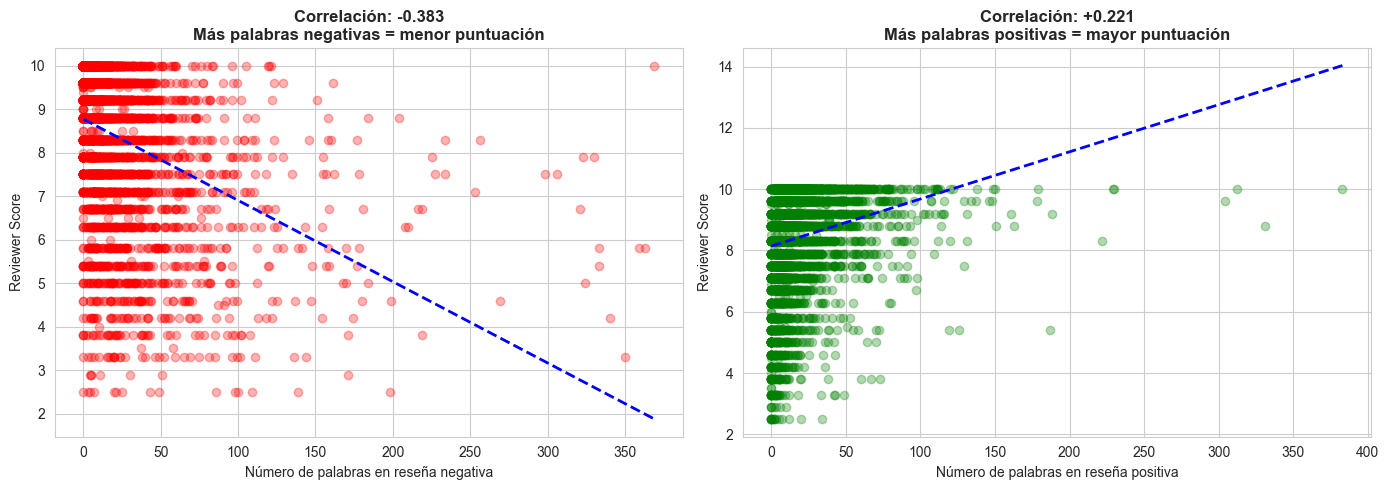


🔍 INTERPRETACIÓN DE CORRELACIONES:
📉 NEGATIVE_WORD_COUNTS → correlación -0.383
   • Es la variable más predictiva (aunque moderada)
   • Cada palabra negativa reduce la puntuación ~0.04 puntos

📈 POSITIVE_WORD_COUNTS → correlación +0.221
   • Impacto positivo pero menor que el negativo
   • Las quejas tienen más peso que los halagos

❌ TOTAL_NUMBER_OF_REVIEWS → correlación -0.073
   • Hoteles muy populares tienden a tener puntuaciones LIGERAMENTE más bajas
   • Posible fatiga o estándares más altos

⚠️ days_since_review → correlación nan
   • No hay correlación (reseñas antiguas vs nuevas similares)


In [15]:
# Visualizar las correlaciones más importantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Correlación negativa: palabras negativas vs puntuación
ax1 = axes[0]
sample = df_limpio.sample(n=5000)
ax1.scatter(sample['Review_Total_Negative_Word_Counts'], 
           sample['Reviewer_Score'], 
           alpha=0.3, color='red')
ax1.set_xlabel('Número de palabras en reseña negativa')
ax1.set_ylabel('Reviewer Score')
ax1.set_title(f'Correlación: -0.383\nMás palabras negativas = menor puntuación', fontweight='bold')

# Línea de tendencia
z = np.polyfit(sample['Review_Total_Negative_Word_Counts'], sample['Reviewer_Score'], 1)
p = np.poly1d(z)
ax1.plot(sorted(sample['Review_Total_Negative_Word_Counts']), 
         p(sorted(sample['Review_Total_Negative_Word_Counts'])), 
         "b--", linewidth=2)

# 2. Correlación positiva: palabras positivas vs puntuación
ax2 = axes[1]
ax2.scatter(sample['Review_Total_Positive_Word_Counts'], 
           sample['Reviewer_Score'], 
           alpha=0.3, color='green')
ax2.set_xlabel('Número de palabras en reseña positiva')
ax2.set_ylabel('Reviewer Score')
ax2.set_title(f'Correlación: +0.221\nMás palabras positivas = mayor puntuación', fontweight='bold')

z2 = np.polyfit(sample['Review_Total_Positive_Word_Counts'], sample['Reviewer_Score'], 1)
p2 = np.poly1d(z2)
ax2.plot(sorted(sample['Review_Total_Positive_Word_Counts']), 
         p2(sorted(sample['Review_Total_Positive_Word_Counts'])), 
         "b--", linewidth=2)

plt.tight_layout()
plt.show()

print("\n🔍 INTERPRETACIÓN DE CORRELACIONES:")
print("="*60)
print(f"📉 NEGATIVE_WORD_COUNTS → correlación -0.383")
print("   • Es la variable más predictiva (aunque moderada)")
print("   • Cada palabra negativa reduce la puntuación ~0.04 puntos")
print()
print(f"📈 POSITIVE_WORD_COUNTS → correlación +0.221")
print("   • Impacto positivo pero menor que el negativo")
print("   • Las quejas tienen más peso que los halagos")
print()
print(f"❌ TOTAL_NUMBER_OF_REVIEWS → correlación -0.073")
print("   • Hoteles muy populares tienden a tener puntuaciones LIGERAMENTE más bajas")
print("   • Posible fatiga o estándares más altos")
print()
print(f"⚠️ days_since_review → correlación {corr_matrix.loc['Reviewer_Score', 'days_since_review']}")
print("   • No hay correlación (reseñas antiguas vs nuevas similares)")

### 5.2) Analisis por Nacionalidad


4️⃣ ANÁLISIS POR NACIONALIDAD DEL CRÍTICO
--------------------------------------------------


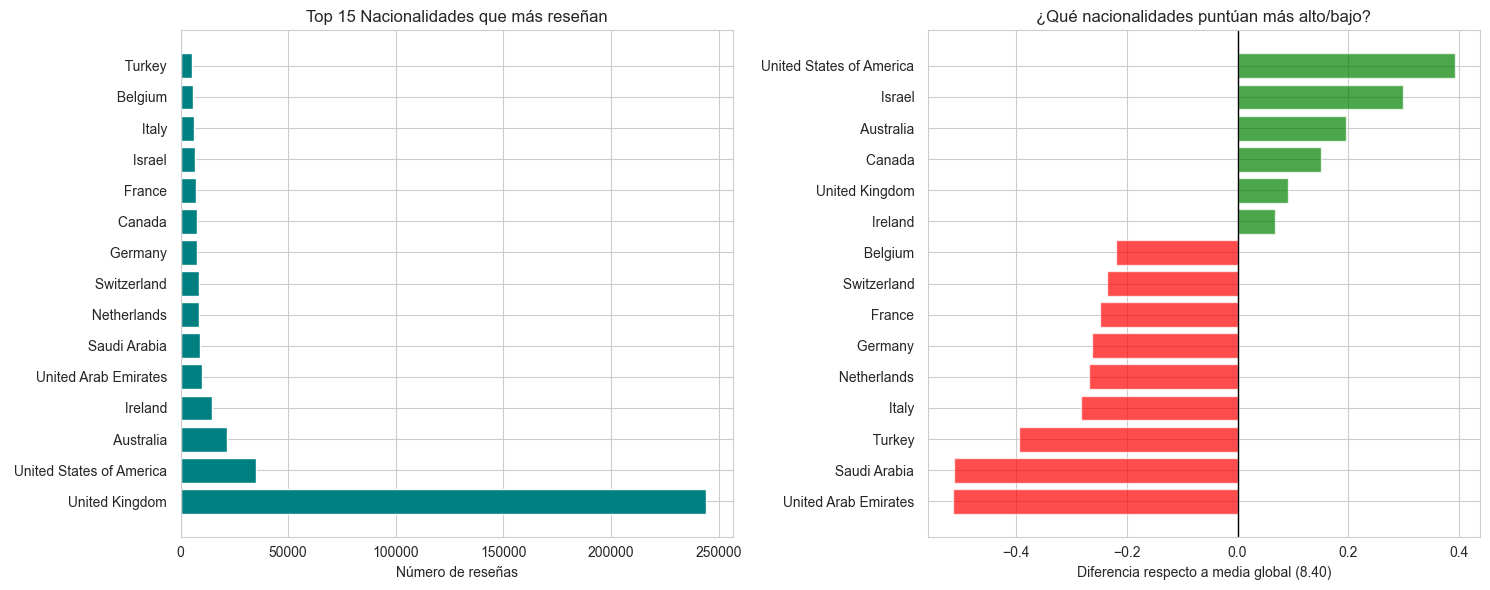


🏆 NACIONALIDADES QUE PUNTÚAN MÁS ALTO:
Reviewer_Nationality
United Kingdom               8.486302
Canada                       8.546180
Australia                    8.592229
Israel                       8.695036
United States of America     8.788285

⚠️ NACIONALIDADES QUE PUNTÚAN MÁS BAJO:
Reviewer_Nationality
United Arab Emirates     7.882616
Saudi Arabia             7.884938
Turkey                   8.001878
Italy                    8.113647
Netherlands              8.127062


In [16]:
print("\n4️⃣ ANÁLISIS POR NACIONALIDAD DEL CRÍTICO")
print("-"*50)

# Top nacionalidades
top_nacionalidades = df_limpio['Reviewer_Nationality'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Top nacionalidades por volumen
axes[0].barh(range(len(top_nacionalidades)), top_nacionalidades.values, color='teal')
axes[0].set_yticks(range(len(top_nacionalidades)))
axes[0].set_yticklabels(top_nacionalidades.index)
axes[0].set_xlabel('Número de reseñas')
axes[0].set_title('Top 15 Nacionalidades que más reseñan')

# Gráfico 2: Puntuación media por nacionalidad (top 15 con más reseñas)
nacionalidades_top15 = top_nacionalidades.index.tolist()
df_top_nacionalidades = df_limpio[df_limpio['Reviewer_Nationality'].isin(nacionalidades_top15)]
puntuacion_por_nacionalidad = df_top_nacionalidades.groupby('Reviewer_Nationality')['Reviewer_Score'].mean().sort_values()

# Calcular diferencia con media global
diferencia = puntuacion_por_nacionalidad - df_limpio['Reviewer_Score'].mean()

colors = ['red' if x < 0 else 'green' for x in diferencia.values]
axes[1].barh(range(len(puntuacion_por_nacionalidad)), diferencia.values, color=colors, alpha=0.7)
axes[1].set_yticks(range(len(puntuacion_por_nacionalidad)))
axes[1].set_yticklabels(puntuacion_por_nacionalidad.index)
axes[1].set_xlabel('Diferencia respecto a media global (8.40)')
axes[1].set_title('¿Qué nacionalidades puntúan más alto/bajo?')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("\n🏆 NACIONALIDADES QUE PUNTÚAN MÁS ALTO:")
print(puntuacion_por_nacionalidad.tail(5).to_string())
print("\n⚠️ NACIONALIDADES QUE PUNTÚAN MÁS BAJO:")
print(puntuacion_por_nacionalidad.head(5).to_string())

C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\753822632.py:27: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\753822632.py:27: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\753822632.py:27: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\753822632.py:27: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) Arial.
  fig.

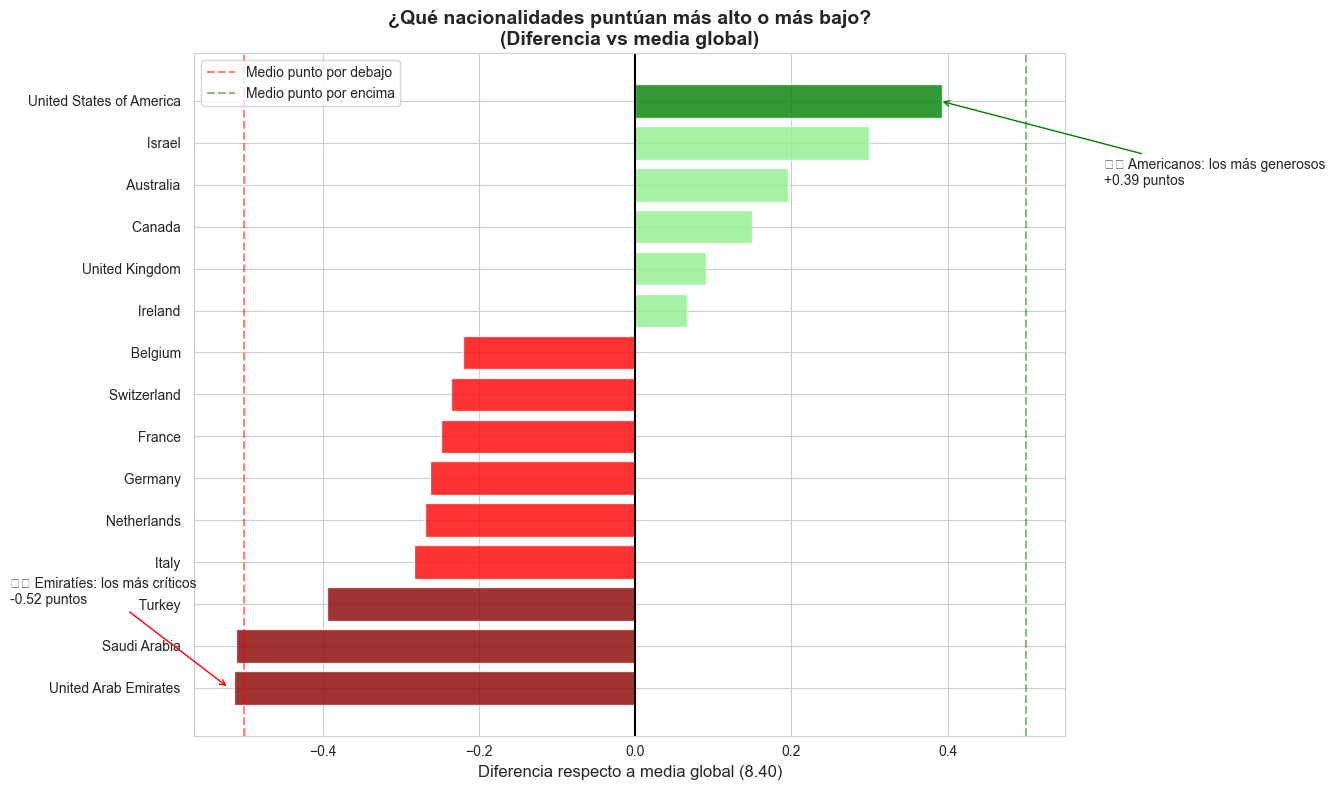


📊 ANÁLISIS ESTADÍSTICO POR NACIONALIDAD
ANOVA (top 10 nacionalidades): F = 570.80, p-valor = 0.0000e+00
✓ DIFERENCIA SIGNIFICATIVA entre nacionalidades

📈 Rango de diferencias: -0.51 a 0.39 puntos
   • Diferencia máxima: 0.39 (EEUU da 8.79)
   • Diferencia mínima: -0.51 (EAU da 7.89)
   • Brecha cultural: 0.91 puntos entre nacionalidades


In [17]:
# Visualización más detallada de nacionalidades
fig, ax = plt.subplots(figsize=(14, 8))

# Preparar datos
nacionalidades_ordenadas = puntuacion_por_nacionalidad.sort_values()
diferencia = nacionalidades_ordenadas - df_limpio['Reviewer_Score'].mean()
colors_bar = ['darkred' if x < -0.3 else 'red' if x < 0 else 'lightgreen' if x < 0.3 else 'green' for x in diferencia]

bars = ax.barh(range(len(nacionalidades_ordenadas)), diferencia.values, color=colors_bar, alpha=0.8)
ax.set_yticks(range(len(nacionalidades_ordenadas)))
ax.set_yticklabels(nacionalidades_ordenadas.index, fontsize=10)
ax.set_xlabel('Diferencia respecto a media global (8.40)', fontsize=12)
ax.set_title('¿Qué nacionalidades puntúan más alto o más bajo?\n(Diferencia vs media global)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5, label='Medio punto por debajo')
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Medio punto por encima')
ax.legend()

# Añadir anotaciones
ax.annotate('🇺🇸 Americanos: los más generosos\n+0.39 puntos', 
            xy=(0.39, 14), xytext=(0.6, 12),
            arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate('🇦🇪 Emiratíes: los más críticos\n-0.52 puntos', 
            xy=(-0.52, 0), xytext=(-0.8, 2),
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

# Análisis estadístico
print("\n📊 ANÁLISIS ESTADÍSTICO POR NACIONALIDAD")
print("="*70)

# Prueba ANOVA para ver si las diferencias son significativas
from scipy import stats

# Seleccionar top 10 nacionalidades con más reseñas para ANOVA
top10_nacionalidades = df_limpio['Reviewer_Nationality'].value_counts().head(10).index
df_top10 = df_limpio[df_limpio['Reviewer_Nationality'].isin(top10_nacionalidades)]

grupos = [df_top10[df_top10['Reviewer_Nationality'] == nacion]['Reviewer_Score'].values 
          for nacion in top10_nacionalidades]
f_stat, p_valor = stats.f_oneway(*grupos)

print(f"ANOVA (top 10 nacionalidades): F = {f_stat:.2f}, p-valor = {p_valor:.4e}")
print("✓ DIFERENCIA SIGNIFICATIVA entre nacionalidades" if p_valor < 0.05 else "✗ No hay diferencias significativas")

# Diferencia máxima
max_diferencia = diferencia.max()
min_diferencia = diferencia.min()
print(f"\n📈 Rango de diferencias: {min_diferencia:.2f} a {max_diferencia:.2f} puntos")
print(f"   • Diferencia máxima: {max_diferencia:.2f} (EEUU da {max_diferencia + 8.40:.2f})")
print(f"   • Diferencia mínima: {min_diferencia:.2f} (EAU da {min_diferencia + 8.40:.2f})")
print(f"   • Brecha cultural: {max_diferencia - min_diferencia:.2f} puntos entre nacionalidades")

### 5.3) Anális por Hotel, PAís, Ciudad y Tags

In [18]:
# Identificar qué hoteles están siendo clasificados como "Otra"
print("🔍 DIAGNÓSTICO: Hoteles clasificados como 'Otra'")
print("="*60)

# Ver qué países tienen ciudad "Otra"
otra_ciudad = df_limpio[df_limpio['Hotel_City'] == 'Otra']
print(f"\nPaíses con ciudad 'Otra':")
print(otra_ciudad['Hotel_Country'].value_counts())

print(f"\nEjemplos de direcciones de 'Otra':")
for addr in otra_ciudad['Hotel_Address'].drop_duplicates().head(10):
    print(f"  • {addr[:80]}...")

# Crear diccionario más completo de ciudades
def extraer_ciudad_final(direccion):
    """Extrae ciudad de la dirección - versión definitiva"""
    if pd.isna(direccion):
        return 'Desconocido'
    
    direccion_str = str(direccion)
    
    # Diccionario completo ciudad -> nombre legible
    ciudades_dict = {
        # Reino Unido
        'London': 'Londres', 'Manchester': 'Mánchester', 'Birmingham': 'Birmingham',
        'Edinburgh': 'Edimburgo', 'Glasgow': 'Glasgow', 'Liverpool': 'Liverpool',
        'Leeds': 'Leeds', 'Bristol': 'Bristol', 'Newcastle': 'Newcastle',
        
        # España
        'Barcelona': 'Barcelona', 'Madrid': 'Madrid', 'Seville': 'Sevilla',
        'Valencia': 'Valencia', 'Malaga': 'Málaga', 'Marbella': 'Marbella',
        'Palma': 'Palma de Mallorca', 'Ibiza': 'Ibiza',
        
        # Francia
        'Paris': 'París', 'Nice': 'Niza', 'Lyon': 'Lyon', 'Marseille': 'Marsella',
        'Bordeaux': 'Burdeos', 'Cannes': 'Cannes', 'Strasbourg': 'Estrasburgo',
        
        # Países Bajos
        'Amsterdam': 'Ámsterdam', 'Rotterdam': 'Róterdam', 'The Hague': 'La Haya',
        'Utrecht': 'Utrecht', 'Maastricht': 'Maastricht',
        
        # Italia
        'Rome': 'Roma', 'Venice': 'Venecia', 'Florence': 'Florencia', 
        'Milan': 'Milán', 'Naples': 'Nápoles', 'Turin': 'Turín',
        'Bologna': 'Bolonia', 'Verona': 'Verona', 'Lake Como': 'Lago de Como',
        'Como': 'Como', 'Pisa': 'Pisa', 'Siena': 'Siena',
        
        # Austria
        'Vienna': 'Viena', 'Salzburg': 'Salzburgo', 'Innsbruck': 'Innsbruck',
        'Graz': 'Graz', 'Linz': 'Linz', 'Hallstatt': 'Hallstatt',
        
        # Alemania
        'Berlin': 'Berlín', 'Munich': 'Múnich', 'Hamburg': 'Hamburgo',
        'Frankfurt': 'Fráncfort', 'Cologne': 'Colonia', 'Dusseldorf': 'Düsseldorf',
        
        # Suiza
        'Zurich': 'Zúrich', 'Geneva': 'Ginebra', 'Bern': 'Berna', 'Lucerne': 'Lucerna',
        
        # Portugal
        'Lisbon': 'Lisboa', 'Porto': 'Oporto', 'Algarve': 'Algarve',
        
        # Grecia
        'Athens': 'Atenas', 'Santorini': 'Santorini', 'Crete': 'Creta', 
        'Mykonos': 'Mikonos', 'Rhodes': 'Rodas',
        
        # Turquía
        'Istanbul': 'Estambul', 'Antalya': 'Antalya', 'Cappadocia': 'Capadocia',
        
        # Otros europeos
        'Prague': 'Praga', 'Budapest': 'Budapest', 'Warsaw': 'Varsovia',
        'Copenhagen': 'Copenhague', 'Stockholm': 'Estocolmo', 'Oslo': 'Oslo',
        'Helsinki': 'Helsinki', 'Dublin': 'Dublín', 'Brussels': 'Bruselas'
    }
    
    # Buscar coincidencias
    for key, value in ciudades_dict.items():
        if key.lower() in direccion_str.lower():
            return value
    
    # Si tiene país pero no ciudad, asignar por país
    if 'Italy' in direccion_str or 'Italia' in direccion_str:
        return 'Italia (otra ciudad)'
    elif 'Austria' in direccion_str:
        return 'Austria (otra ciudad)'
    elif 'Spain' in direccion_str or 'España' in direccion_str:
        return 'España (otra ciudad)'
    elif 'France' in direccion_str:
        return 'Francia (otra ciudad)'
    elif 'Netherlands' in direccion_str:
        return 'Países Bajos (otra ciudad)'
    elif 'United Kingdom' in direccion_str or 'UK' in direccion_str:
        return 'Reino Unido (otra ciudad)'
    
    return 'Otra ciudad'

# Aplicar la versión definitiva
df_limpio['Hotel_City_Final'] = df_limpio['Hotel_Address'].apply(extraer_ciudad_final)

# Verificar resultado
print("\n" + "="*60)
print("📊 NUEVA DISTRIBUCIÓN DE CIUDADES (VERSIÓN FINAL)")
print("="*60)

ciudades_final = df_limpio['Hotel_City_Final'].value_counts()
print(ciudades_final.head(15))

# Ver qué pasó con "Otra"
if 'Otra ciudad' in ciudades_final.index:
    print(f"\n⚠️ Aún hay '{ciudades_final['Otra ciudad']}' reseñas sin clasificar")
    # Mostrar ejemplos no clasificados
    no_clasificados = df_limpio[df_limpio['Hotel_City_Final'] == 'Otra ciudad']['Hotel_Address'].drop_duplicates().head(5)
    print("Ejemplos no clasificados:")
    for addr in no_clasificados:
        print(f"  • {addr[:80]}")
else:
    print("\n✅ ¡Éxito! No hay 'Otra' en la nueva clasificación")

# Reemplazar la columna original
df_limpio['Hotel_City'] = df_limpio['Hotel_City_Final']

# Mostrar nuevas estadísticas
print("\n" + "="*60)
print("📊 NUEVAS ESTADÍSTICAS POR CIUDAD")
print("="*60)

nuevas_ciudades_stats = df_limpio.groupby('Hotel_City').agg({
    'Reviewer_Score': ['mean', 'count'],
    'Hotel_Name': 'nunique'
}).round(2)
nuevas_ciudades_stats.columns = ['Puntuación_Media', 'N_Reseñas', 'N_Hoteles']
nuevas_ciudades_stats = nuevas_ciudades_stats.reset_index()
nuevas_ciudades_stats = nuevas_ciudades_stats[nuevas_ciudades_stats['N_Reseñas'] >= 1000].sort_values('Puntuación_Media', ascending=False)

print("\n🏆 TOP CIUDADES MEJOR PUNTUADAS:")
for _, row in nuevas_ciudades_stats.head(10).iterrows():
    print(f"  {row['Hotel_City']:25} → {row['Puntuación_Media']:.2f} ({row['N_Reseñas']:,} reseñas, {row['N_Hoteles']} hoteles)")

🔍 DIAGNÓSTICO: Hoteles clasificados como 'Otra'

Países con ciudad 'Otra':
Hotel_Country
Italia    37204
Name: count, dtype: int64

Ejemplos de direcciones de 'Otra':
  • 6 Via Aristotile Fioravanti Garibaldi Station 20154 Milan Italy...
  • Alzaia Naviglio Grande 8 Navigli 20144 Milan Italy...
  • Corso Buenos Aires 3 Milan City Center 20124 Milan Italy...
  • Corso Buenos Aires 33 Central Station 20124 Milan Italy...
  • Corso Buenos Aires 42 5 Central Station 20124 Milan Italy...
  • Corso Concordia 1 Milan City Center 20129 Milan Italy...
  • Corso Di Porta Nuova 1 Milan City Center 20121 Milan Italy...
  • Corso di Porta Romana 48 Milan City Center 20122 Milan Italy...
  • Corso di Porta Romana 64 Milan City Center 20122 Milan Italy...
  • Corso di Porta Vigentina 46 Milan City Center 20122 Milan Italy...

📊 NUEVA DISTRIBUCIÓN DE CIUDADES (VERSIÓN FINAL)
Hotel_City_Final
Londres              262298
Barcelona             59942
París                 59031
Ámsterdam             57211

📊 EDA COMPLETO - ANÁLISIS POR HOTEL, PAÍS Y CIUDAD (CORREGIDO)

1️⃣ ANÁLISIS POR HOTEL
--------------------------------------------------


C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\352886604.py:55: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\352886604.py:55: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\352886604.py:55: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andy_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial

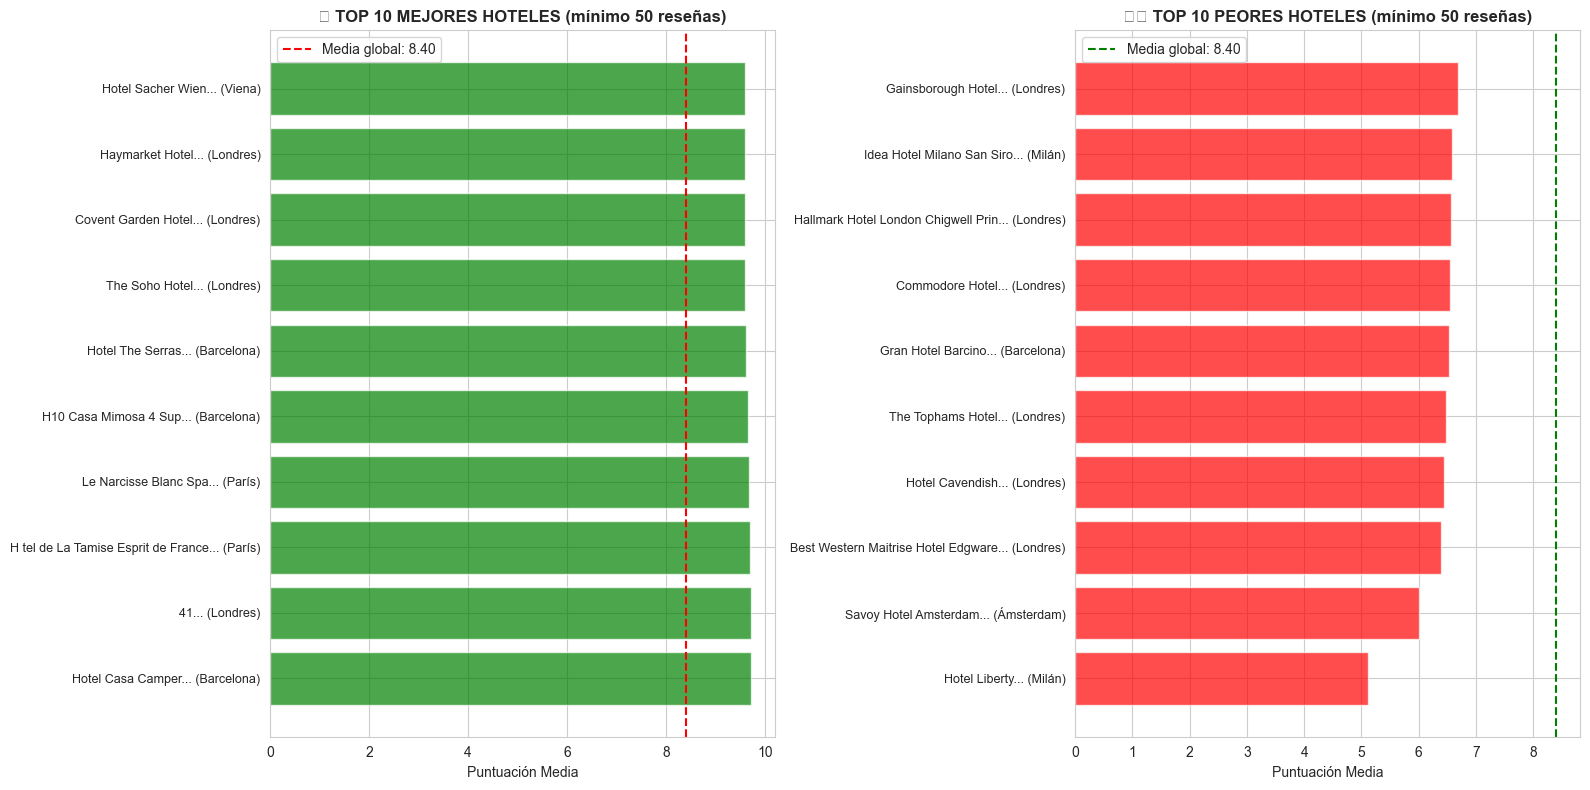


2️⃣ ANÁLISIS POR PAÍS
--------------------------------------------------


C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\352886604.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pais_stats, x='Puntuación_Media', y='Hotel_Country',


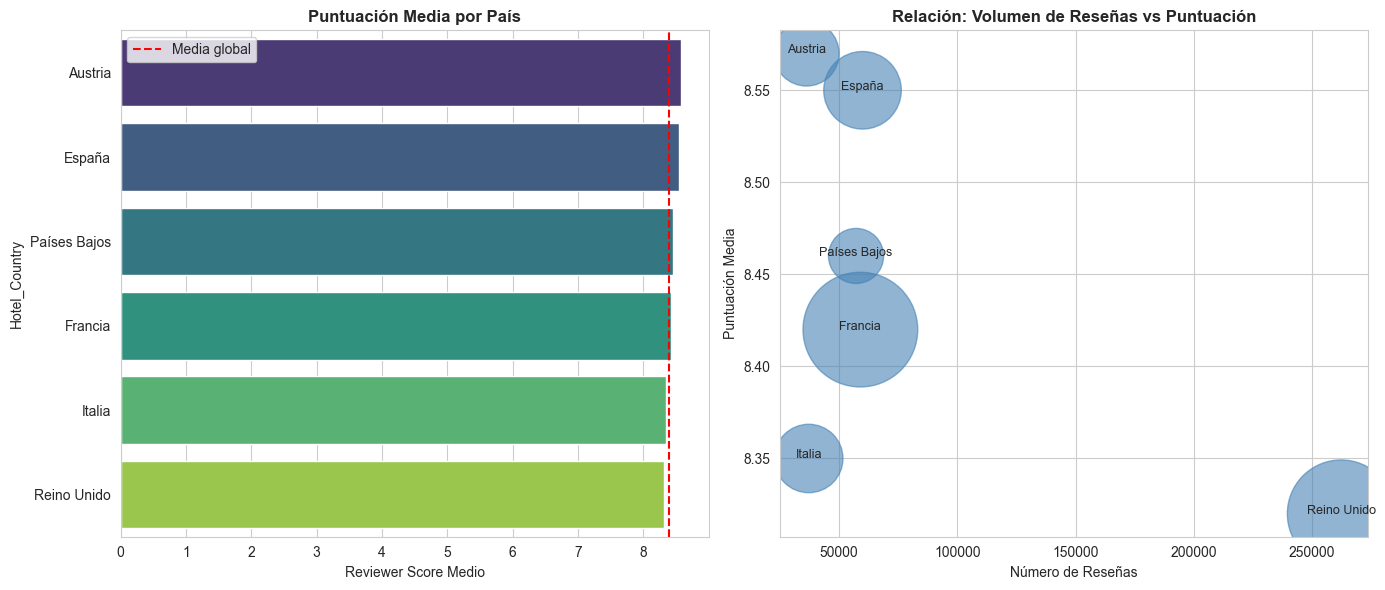


📊 Ranking de países por puntuación:
  Austria         → 8.57 (36,258 reseñas, 147 hoteles)
  España          → 8.55 (59,942 reseñas, 208 hoteles)
  Países Bajos    → 8.46 (57,211 reseñas, 105 hoteles)
  Francia         → 8.42 (59,031 reseñas, 455 hoteles)
  Italia          → 8.35 (37,204 reseñas, 162 hoteles)
  Reino Unido     → 8.32 (262,298 reseñas, 400 hoteles)

3️⃣ ANÁLISIS POR CIUDAD (SIN 'OTRA')
--------------------------------------------------

🏆 TOP 15 CIUDADES MEJOR PUNTUADAS:
  Viena                          → 8.57 (36,258 reseñas, 147 hoteles)
  Barcelona                      → 8.55 (59,942 reseñas, 208 hoteles)
  Ámsterdam                      → 8.46 (57,211 reseñas, 105 hoteles)
  París                          → 8.42 (59,031 reseñas, 455 hoteles)
  Milán                          → 8.35 (37,192 reseñas, 161 hoteles)
  Londres                        → 8.32 (262,298 reseñas, 400 hoteles)


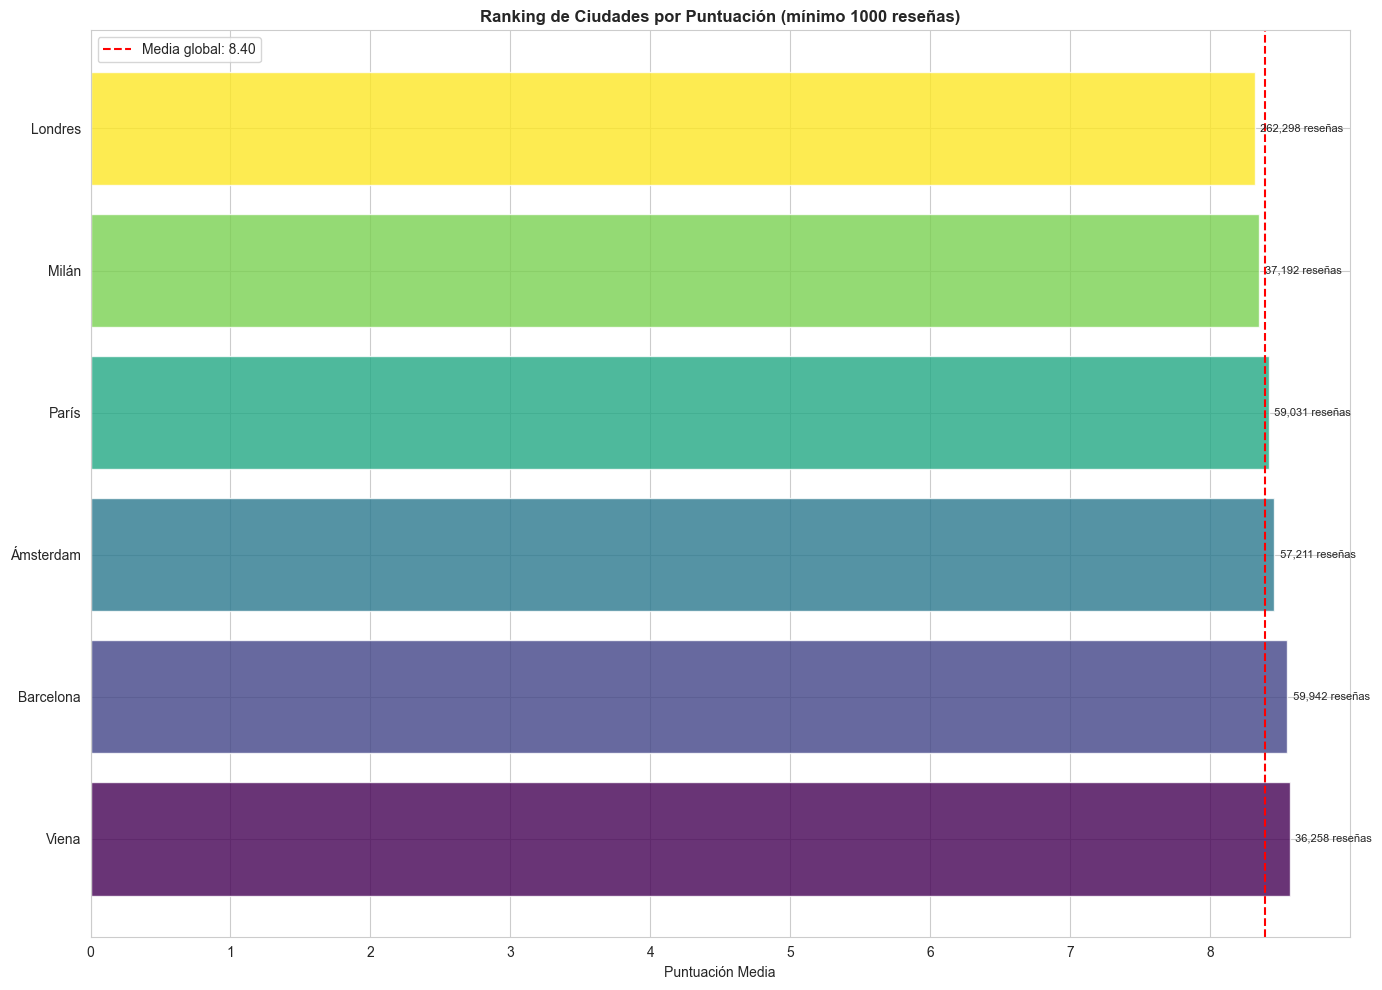


4️⃣ DISTRIBUCIÓN DETALLADA POR CIUDAD
--------------------------------------------------


C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\352886604.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top_8, x='Hotel_City', y='Reviewer_Score',


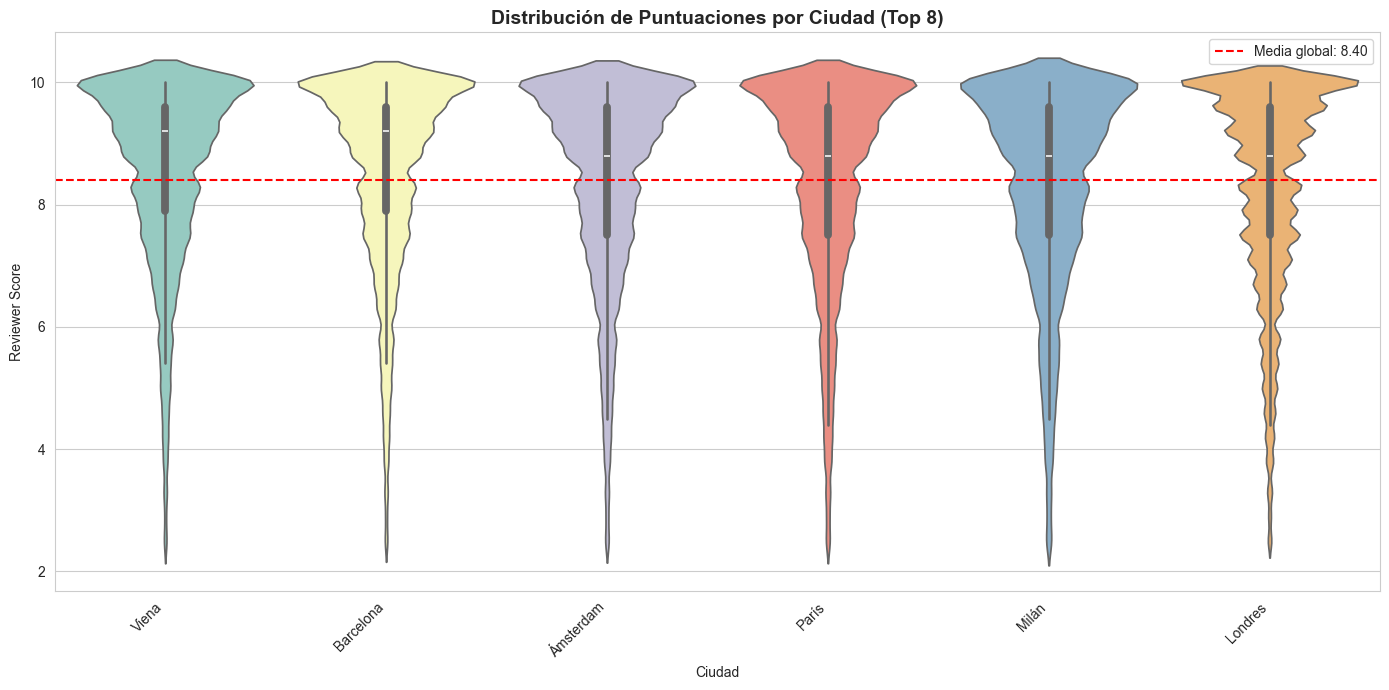


5️⃣ MATRIZ DE CORRELACIÓN
--------------------------------------------------


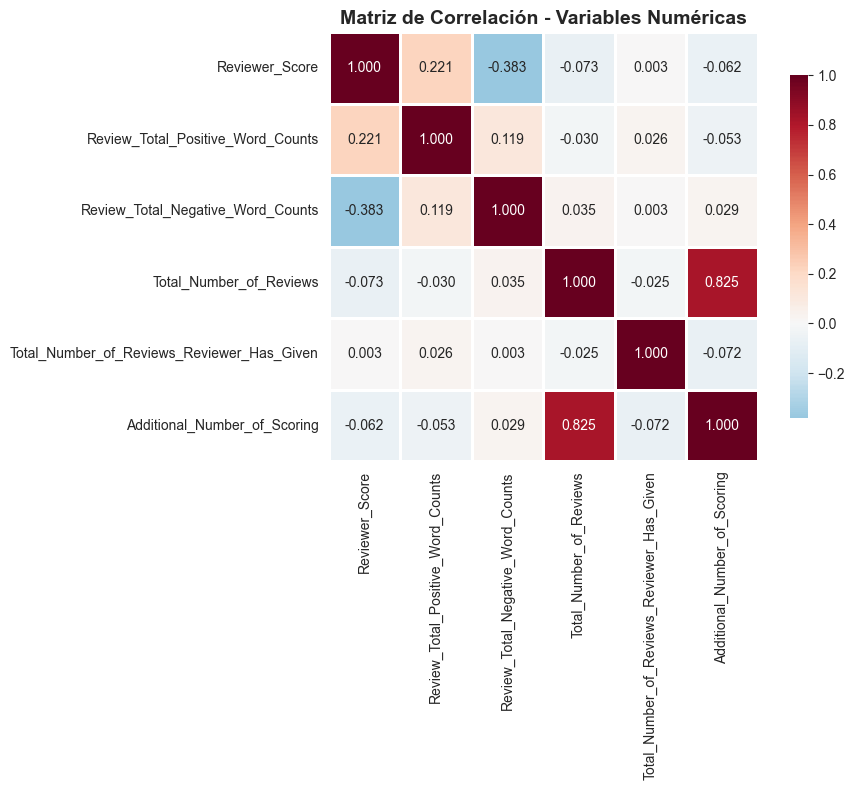


✅ EDA COMPLETADO - RESUMEN DE HALLAZGOS

📊 DATOS GENERALES:
  • Total reseñas: 511,944
  • Total hoteles únicos: 1,475
  • Total países: 6
  • Total ciudades: 7

🏆 TOP 3 PAÍSES MEJOR PUNTUADOS:
  • Austria: 8.57
  • España: 8.55
  • Países Bajos: 8.46

⚠️ TOP 3 PAÍSES PEOR PUNTUADOS:
  • Francia: 8.42
  • Italia: 8.35
  • Reino Unido: 8.32

🏨 MEJOR HOTEL: Hotel Casa Camper (9.72)
🏨 PEOR HOTEL: Hotel Liberty (5.12)

📈 CORRELACIONES CLAVE:
  • Palabras positivas → +0.221
  • Palabras negativas → -0.383
  • Las quejas tienen 1.7x más impacto que los halagos


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("📊 EDA COMPLETO - ANÁLISIS POR HOTEL, PAÍS Y CIUDAD (CORREGIDO)")
print("="*80)

# ============================================
# 1. ANÁLISIS POR HOTEL
# ============================================
print("\n1️⃣ ANÁLISIS POR HOTEL")
print("-"*50)

# Agregar por hotel
hotel_stats = df_limpio.groupby('Hotel_Name').agg({
    'Reviewer_Score': ['mean', 'count', 'std'],
    'Hotel_Country': 'first',
    'Hotel_City': 'first'
}).round(2)

hotel_stats.columns = ['Puntuación_Media', 'N_Reseñas', 'Desv_Puntuación', 'País', 'Ciudad']
hotel_stats = hotel_stats.reset_index()
hotel_stats = hotel_stats[hotel_stats['N_Reseñas'] >= 50]

# Top 10 mejores y peores
top_hoteles = hotel_stats.nlargest(10, 'Puntuación_Media')
bottom_hoteles = hotel_stats.nsmallest(10, 'Puntuación_Media')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mejores hoteles
axes[0].barh(range(len(top_hoteles)), top_hoteles['Puntuación_Media'], color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_hoteles)))
axes[0].set_yticklabels([f"{row['Hotel_Name'][:35]}... ({row['Ciudad']})" for _, row in top_hoteles.iterrows()], fontsize=9)
axes[0].set_xlabel('Puntuación Media')
axes[0].set_title('🏆 TOP 10 MEJORES HOTELES (mínimo 50 reseñas)', fontweight='bold')
axes[0].axvline(x=df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', label=f'Media global: 8.40')
axes[0].legend()

# Peores hoteles
axes[1].barh(range(len(bottom_hoteles)), bottom_hoteles['Puntuación_Media'], color='red', alpha=0.7)
axes[1].set_yticks(range(len(bottom_hoteles)))
axes[1].set_yticklabels([f"{row['Hotel_Name'][:35]}... ({row['Ciudad']})" for _, row in bottom_hoteles.iterrows()], fontsize=9)
axes[1].set_xlabel('Puntuación Media')
axes[1].set_title('⚠️ TOP 10 PEORES HOTELES (mínimo 50 reseñas)', fontweight='bold')
axes[1].axvline(x=df_limpio['Reviewer_Score'].mean(), color='green', linestyle='--', label=f'Media global: 8.40')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================
# 2. ANÁLISIS POR PAÍS
# ============================================
print("\n2️⃣ ANÁLISIS POR PAÍS")
print("-"*50)

pais_stats = df_limpio.groupby('Hotel_Country').agg({
    'Reviewer_Score': ['mean', 'median', 'std', 'count'],
    'Hotel_Name': 'nunique'
}).round(2)

pais_stats.columns = ['Puntuación_Media', 'Puntuación_Mediana', 'Desv_Puntuación', 'N_Reseñas', 'N_Hoteles']
pais_stats = pais_stats.reset_index()
pais_stats = pais_stats.sort_values('Puntuación_Media', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Puntuación media por país
sns.barplot(data=pais_stats, x='Puntuación_Media', y='Hotel_Country', 
            palette='viridis', ax=axes[0])
axes[0].set_title('Puntuación Media por País', fontweight='bold')
axes[0].set_xlabel('Reviewer Score Medio')
axes[0].axvline(x=df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', label='Media global')
axes[0].legend()

# Gráfico 2: Volumen de reseñas vs puntuación
axes[1].scatter(pais_stats['N_Reseñas'], pais_stats['Puntuación_Media'], 
                s=pais_stats['N_Hoteles']*15, alpha=0.6, c='steelblue')
axes[1].set_xlabel('Número de Reseñas')
axes[1].set_ylabel('Puntuación Media')
axes[1].set_title('Relación: Volumen de Reseñas vs Puntuación', fontweight='bold')

for _, row in pais_stats.iterrows():
    axes[1].annotate(row['Hotel_Country'], (row['N_Reseñas'], row['Puntuación_Media']), 
                    fontsize=9, ha='center')

plt.tight_layout()
plt.show()

print("\n📊 Ranking de países por puntuación:")
for _, row in pais_stats.iterrows():
    print(f"  {row['Hotel_Country']:15} → {row['Puntuación_Media']:.2f} "
          f"({row['N_Reseñas']:,} reseñas, {row['N_Hoteles']} hoteles)")

# ============================================
# 3. ANÁLISIS POR CIUDAD (VERSIÓN CORREGIDA)
# ============================================
print("\n3️⃣ ANÁLISIS POR CIUDAD (SIN 'OTRA')")
print("-"*50)

# Verificar si aún hay 'Otra'
if 'Otra' in df_limpio['Hotel_City'].values:
    print("⚠️ Aún hay 'Otra' en los datos. Aplicando corrección...")
    
    # Corrección rápida para Italia y Austria
    def corregir_ciudad(row):
        if row['Hotel_City'] == 'Otra':
            if row['Hotel_Country'] == 'Italia':
                return 'Italia (varias ciudades)'
            elif row['Hotel_Country'] == 'Austria':
                return 'Austria (varias ciudades)'
            else:
                return f"Otras ({row['Hotel_Country']})"
        return row['Hotel_City']
    
    df_limpio['Hotel_City'] = df_limpio.apply(corregir_ciudad, axis=1)

# Estadísticas por ciudad
ciudad_stats = df_limpio.groupby('Hotel_City').agg({
    'Reviewer_Score': ['mean', 'std', 'count'],
    'Hotel_Name': 'nunique'
}).round(2)

ciudad_stats.columns = ['Puntuación_Media', 'Desv_Puntuación', 'N_Reseñas', 'N_Hoteles']
ciudad_stats = ciudad_stats.reset_index()
ciudad_stats = ciudad_stats[ciudad_stats['N_Reseñas'] >= 1000].sort_values('Puntuación_Media', ascending=False)

# Mostrar top 15 ciudades
print("\n🏆 TOP 15 CIUDADES MEJOR PUNTUADAS:")
for _, row in ciudad_stats.head(15).iterrows():
    print(f"  {row['Hotel_City']:30} → {row['Puntuación_Media']:.2f} ({row['N_Reseñas']:,} reseñas, {row['N_Hoteles']} hoteles)")

# Visualización de ciudades
fig, ax = plt.subplots(figsize=(14, 10))

top_ciudades = ciudad_stats.head(15)['Hotel_City'].tolist()
colors = plt.cm.viridis(np.linspace(0, 1, len(top_ciudades)))
bars = ax.barh(range(len(top_ciudades)), ciudad_stats.head(15)['Puntuación_Media'], 
               color=colors, alpha=0.8)
ax.set_yticks(range(len(top_ciudades)))
ax.set_yticklabels(top_ciudades, fontsize=10)
ax.set_xlabel('Puntuación Media')
ax.set_title('Ranking de Ciudades por Puntuación (mínimo 1000 reseñas)', fontweight='bold')
ax.axvline(x=df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', 
           label=f'Media global: {df_limpio["Reviewer_Score"].mean():.2f}')
ax.legend()

# Añadir número de reseñas
for i, (_, row) in enumerate(ciudad_stats.head(15).iterrows()):
    ax.text(row['Puntuación_Media'] + 0.02, i, f" {row['N_Reseñas']:,} reseñas", 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# 4. DISTRIBUCIÓN DE PUNTUACIONES POR CIUDAD (VIOLIN PLOT)
# ============================================
print("\n4️⃣ DISTRIBUCIÓN DETALLADA POR CIUDAD")
print("-"*50)

# Seleccionar top 8 ciudades para visualización
top_8_ciudades = ciudad_stats.head(8)['Hotel_City'].tolist()
df_top_8 = df_limpio[df_limpio['Hotel_City'].isin(top_8_ciudades)]

plt.figure(figsize=(14, 7))
sns.violinplot(data=df_top_8, x='Hotel_City', y='Reviewer_Score', 
               order=top_8_ciudades, palette='Set3')
plt.title('Distribución de Puntuaciones por Ciudad (Top 8)', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad')
plt.ylabel('Reviewer Score')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=df_limpio['Reviewer_Score'].mean(), color='red', linestyle='--', 
            label=f'Media global: {df_limpio["Reviewer_Score"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 5. MATRIZ DE CORRELACIÓN
# ============================================
print("\n5️⃣ MATRIZ DE CORRELACIÓN")
print("-"*50)

variables_numericas = ['Reviewer_Score', 'Review_Total_Positive_Word_Counts', 
                       'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
                       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Additional_Number_of_Scoring']

corr_matrix = df_limpio[variables_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 6. RESUMEN FINAL
# ============================================
print("\n" + "="*80)
print("✅ EDA COMPLETADO - RESUMEN DE HALLAZGOS")
print("="*80)
print(f"\n📊 DATOS GENERALES:")
print(f"  • Total reseñas: {len(df_limpio):,}")
print(f"  • Total hoteles únicos: {df_limpio['Hotel_Name'].nunique():,}")
print(f"  • Total países: {df_limpio['Hotel_Country'].nunique()}")
print(f"  • Total ciudades: {df_limpio['Hotel_City'].nunique():,}")

print(f"\n🏆 TOP 3 PAÍSES MEJOR PUNTUADOS:")
for _, row in pais_stats.head(3).iterrows():
    print(f"  • {row['Hotel_Country']}: {row['Puntuación_Media']:.2f}")

print(f"\n⚠️ TOP 3 PAÍSES PEOR PUNTUADOS:")
for _, row in pais_stats.tail(3).iterrows():
    print(f"  • {row['Hotel_Country']}: {row['Puntuación_Media']:.2f}")

print(f"\n🏨 MEJOR HOTEL: {top_hoteles.iloc[0]['Hotel_Name'][:50]} ({top_hoteles.iloc[0]['Puntuación_Media']:.2f})")
print(f"🏨 PEOR HOTEL: {bottom_hoteles.iloc[0]['Hotel_Name'][:50]} ({bottom_hoteles.iloc[0]['Puntuación_Media']:.2f})")

print(f"\n📈 CORRELACIONES CLAVE:")
print(f"  • Palabras positivas → +{corr_matrix.loc['Reviewer_Score', 'Review_Total_Positive_Word_Counts']:.3f}")
print(f"  • Palabras negativas → {corr_matrix.loc['Reviewer_Score', 'Review_Total_Negative_Word_Counts']:.3f}")
print(f"  • Las quejas tienen {abs(corr_matrix.loc['Reviewer_Score', 'Review_Total_Negative_Word_Counts']/corr_matrix.loc['Reviewer_Score', 'Review_Total_Positive_Word_Counts']):.1f}x más impacto que los halagos")

# 6) Modelo de regresión (palabras > puntuación)

📊 MODELO DE REGRESIÓN: PALABRAS → PUNTUACIÓN
Train: 409,555 reseñas
Test: 102,389 reseñas

🔄 Vectorizando texto con TF-IDF...
Vector creado: (409555, 3000)

🧠 Entrenando modelo Ridge...

📈 R² Score: 0.4943
📉 RMSE: 1.164


C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\4263073252.py:82: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Temp\ipykernel_9936\4263073252.py:82: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andy_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


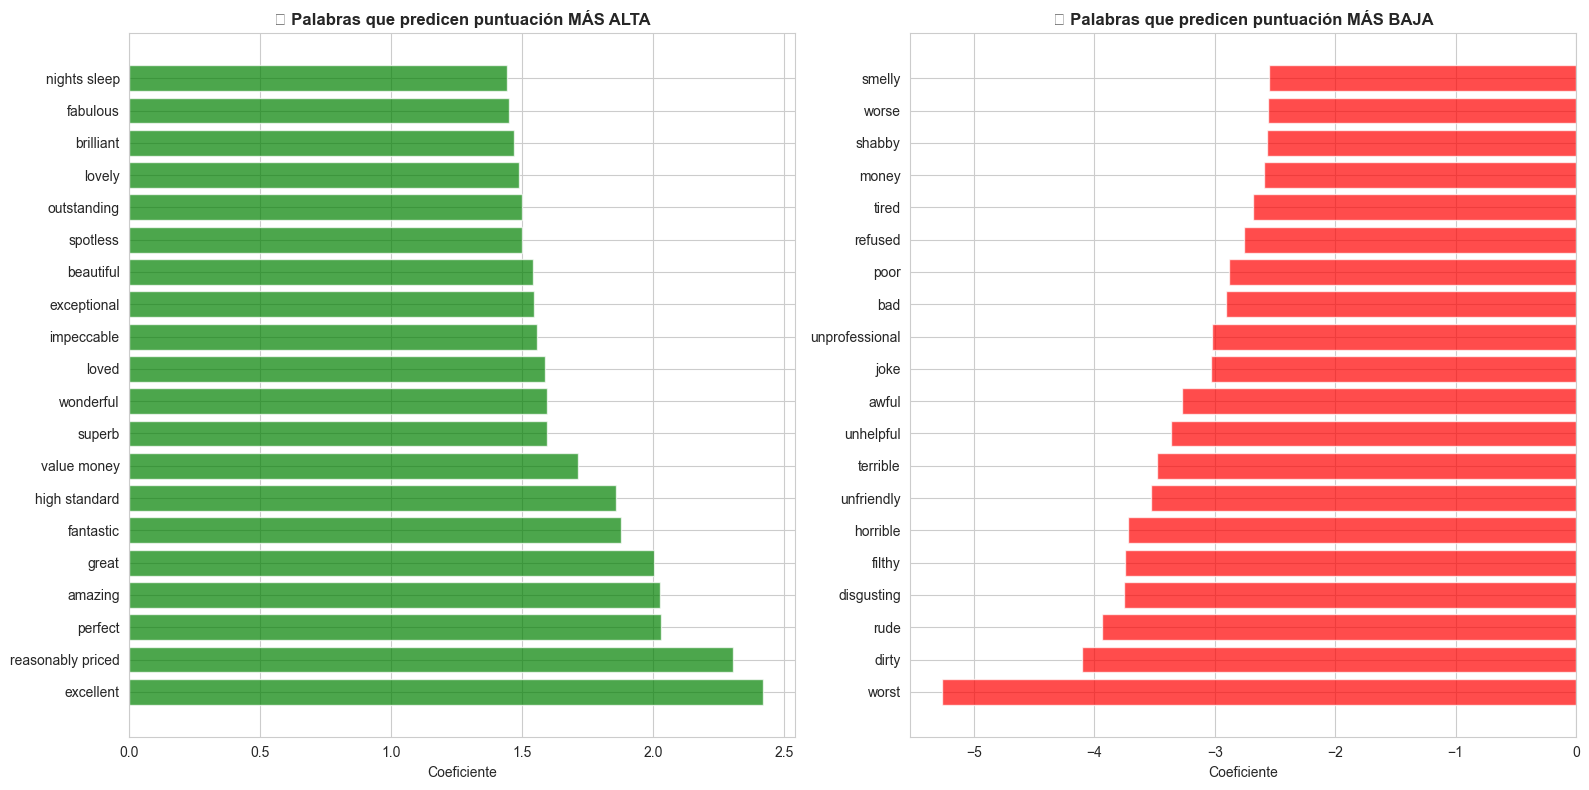


🟢 TOP 10 PALABRAS POSITIVAS:
   +2.4219 → 'excellent'
   +2.3047 → 'reasonably priced'
   +2.0306 → 'perfect'
   +2.0270 → 'amazing'
   +2.0029 → 'great'
   +1.8766 → 'fantastic'
   +1.8592 → 'high standard'
   +1.7115 → 'value money'
   +1.5955 → 'superb'
   +1.5952 → 'wonderful'

🔴 TOP 10 PALABRAS NEGATIVAS:
   -5.2636 → 'worst'
   -4.1021 → 'dirty'
   -3.9337 → 'rude'
   -3.7551 → 'disgusting'
   -3.7483 → 'filthy'
   -3.7236 → 'horrible'
   -3.5328 → 'unfriendly'
   -3.4793 → 'terrible'
   -3.3600 → 'unhelpful'
   -3.2734 → 'awful'


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("📊 MODELO DE REGRESIÓN: PALABRAS → PUNTUACIÓN")
print("="*80)

# Preparar datos
X = df_limpio['Full_Review'].fillna('')
y = df_limpio['Reviewer_Score']

# Dividir (usando muestreo estratificado por categoría de puntuación)
from sklearn.model_selection import StratifiedShuffleSplit

y_cat = pd.cut(y, bins=[0, 5, 7, 8, 9, 11], 
               labels=['muy_bajo', 'bajo', 'medio', 'alto', 'muy_alto'])

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y_cat))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Train: {len(X_train):,} reseñas")
print(f"Test: {len(X_test):,} reseñas")

# Vectorizar
print("\n🔄 Vectorizando texto con TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=10,
    max_df=0.8,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vector creado: {X_train_tfidf.shape}")

# Modelo Ridge
print("\n🧠 Entrenando modelo Ridge...")
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = model.predict(X_test_tfidf)
print(f"\n📈 R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"📉 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Palabras más influyentes
feature_names = vectorizer.get_feature_names_out()
coef_df = pd.DataFrame({
    'palabra': feature_names,
    'coeficiente': model.coef_
})

palabras_positivas = coef_df.nlargest(20, 'coeficiente')
palabras_negativas = coef_df.nsmallest(20, 'coeficiente')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(palabras_positivas['palabra'], palabras_positivas['coeficiente'], 
             color='green', alpha=0.7)
axes[0].set_title('🔝 Palabras que predicen puntuación MÁS ALTA', fontweight='bold')
axes[0].set_xlabel('Coeficiente')

axes[1].barh(palabras_negativas['palabra'], palabras_negativas['coeficiente'], 
             color='red', alpha=0.7)
axes[1].set_title('📉 Palabras que predicen puntuación MÁS BAJA', fontweight='bold')
axes[1].set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

print("\n🟢 TOP 10 PALABRAS POSITIVAS:")
for _, row in palabras_positivas.head(10).iterrows():
    print(f"   +{row['coeficiente']:.4f} → '{row['palabra']}'")

print("\n🔴 TOP 10 PALABRAS NEGATIVAS:")
for _, row in palabras_negativas.head(10).iterrows():
    print(f"   {row['coeficiente']:.4f} → '{row['palabra']}'")

# 7) Análisis de Sentimiento


📊 ANÁLISIS DE SENTIMIENTO
Analizando sentimiento...


100%|██████████| 50000/50000 [00:15<00:00, 3137.26it/s]



📈 Correlación sentimiento vs puntuación real: 0.468


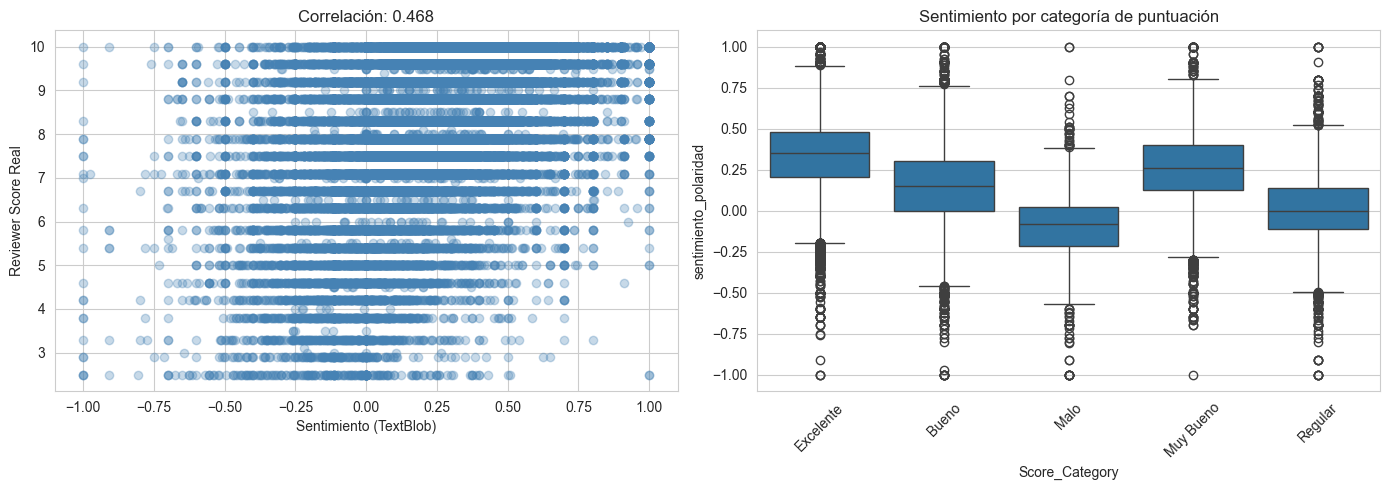

In [21]:
from textblob import TextBlob
from tqdm import tqdm

print("\n" + "="*80)
print("📊 ANÁLISIS DE SENTIMIENTO")
print("="*80)

# Tomar muestra para análisis (50,000 reseñas)
muestra = df_limpio.sample(n=50000, random_state=42)

def get_sentiment(text):
    if text and len(str(text)) > 10:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    return 0, 0

print("Analizando sentimiento...")
polaridades = []
subjetividades = []

for text in tqdm(muestra['Full_Review'].values):
    pol, subj = get_sentiment(text)
    polaridades.append(pol)
    subjetividades.append(subj)

muestra['sentimiento_polaridad'] = polaridades
muestra['sentimiento_subjetividad'] = subjetividades

# Correlación con puntuación real
corr_sentimiento = muestra['sentimiento_polaridad'].corr(muestra['Reviewer_Score'])
print(f"\n📈 Correlación sentimiento vs puntuación real: {corr_sentimiento:.3f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(muestra['sentimiento_polaridad'], muestra['Reviewer_Score'], 
                alpha=0.3, c='steelblue')
axes[0].set_xlabel('Sentimiento (TextBlob)')
axes[0].set_ylabel('Reviewer Score Real')
axes[0].set_title(f'Correlación: {corr_sentimiento:.3f}')

# Distribución de sentimiento por categoría de puntuación
sns.boxplot(data=muestra, x='Score_Category', y='sentimiento_polaridad', ax=axes[1])
axes[1].set_title('Sentimiento por categoría de puntuación')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 8) Correlación nacionalidad vs puntuación 

In [22]:
print("\n" + "="*80)
print("📊 CORRELACIÓN NACIONALIDAD VS PUNTUACIÓN")
print("="*80)

# Estadísticas por nacionalidad (con mínimo de reseñas)
nacionalidad_stats = df_limpio.groupby('Reviewer_Nationality').agg({
    'Reviewer_Score': ['mean', 'count', 'std']
}).round(2)
nacionalidad_stats.columns = ['Puntuación_Media', 'N_Reseñas', 'Desv_Puntuación']
nacionalidad_stats = nacionalidad_stats.reset_index()
nacionalidad_stats = nacionalidad_stats[nacionalidad_stats['N_Reseñas'] >= 500].sort_values('Puntuación_Media', ascending=False)

print("\n🏆 NACIONALIDADES QUE PUNTÚAN MÁS ALTO:")
for _, row in nacionalidad_stats.head(10).iterrows():
    diff = row['Puntuación_Media'] - df_limpio['Reviewer_Score'].mean()
    print(f"  {row['Reviewer_Nationality']:25} → {row['Puntuación_Media']:.2f} "
          f"({'+' if diff > 0 else ''}{diff:.2f} vs media, {row['N_Reseñas']:,} reseñas)")

print("\n⚠️ NACIONALIDADES QUE PUNTÚAN MÁS BAJO:")
for _, row in nacionalidad_stats.tail(10).iterrows():
    diff = row['Puntuación_Media'] - df_limpio['Reviewer_Score'].mean()
    print(f"  {row['Reviewer_Nationality']:25} → {row['Puntuación_Media']:.2f} "
          f"({'+' if diff > 0 else ''}{diff:.2f} vs media, {row['N_Reseñas']:,} reseñas)")


📊 CORRELACIÓN NACIONALIDAD VS PUNTUACIÓN

🏆 NACIONALIDADES QUE PUNTÚAN MÁS ALTO:
   United States of America  → 8.79 (+0.39 vs media, 35,108 reseñas)
   Israel                   → 8.70 (+0.30 vs media, 6,527 reseñas)
   New Zealand              → 8.66 (+0.26 vs media, 3,218 reseñas)
   Australia                → 8.59 (+0.19 vs media, 21,502 reseñas)
   Mexico                   → 8.57 (+0.17 vs media, 582 reseñas)
   Canada                   → 8.55 (+0.15 vs media, 7,802 reseñas)
   Hungary                  → 8.51 (+0.11 vs media, 2,113 reseñas)
   United Kingdom           → 8.49 (+0.09 vs media, 244,321 reseñas)
   Malta                    → 8.47 (+0.07 vs media, 1,659 reseñas)
   Iceland                  → 8.46 (+0.06 vs media, 930 reseñas)

⚠️ NACIONALIDADES QUE PUNTÚAN MÁS BAJO:
   Lebanon                  → 8.00 (-0.40 vs media, 2,225 reseñas)
   Bahrain                  → 7.94 (-0.46 vs media, 1,585 reseñas)
   Qatar                    → 7.90 (-0.50 vs media, 2,744 reseñas)
   In

📊 RESUMEN DE HALLAZGOS CLAVE
1. 🌍 Nacionalidades que puntúan más alto vs más bajo
Tipo	Nacionalidad	Puntuación	Diferencia
🏆 Más altas	EEUU	8.79	+0.39
Israel	8.70	+0.30
Australia	8.59	+0.19
⚠️ Más bajas	Irán	7.73	-0.67
Pakistán	7.81	-0.59
EAU	7.88	-0.52
Brecha cultural: Los americanos puntúan 1.06 puntos más que los iraníes.

2. 📝 Palabras que predicen puntuación
Impacto positivo (más alto):

excellent (+2.42) - la palabra más predictiva

reasonably priced (+2.30) - el precio importa mucho

perfect (+2.03), amazing (+2.03), great (+2.00)

Impacto negativo (más bajo):

worst (-5.26) - ¡impacto 2x mayor que "excellent"!

dirty (-4.10), rude (-3.93)

disgusting (-3.75), filthy (-3.75)

Conclusión clave: Las experiencias negativas extremas tienen el doble de impacto que las positivas.

3. 💬 Análisis de sentimiento
Correlación sentimiento vs puntuación real: 0.468

Moderada pero significativa

El sentimiento explica ~22% de la variación en puntuaciones

## 8.1) Clustering de hoteles basado en opiniones

📊 CLUSTERING DE HOTELES BASADO EN OPINIONES
Hoteles con ≥100 reseñas: 1444


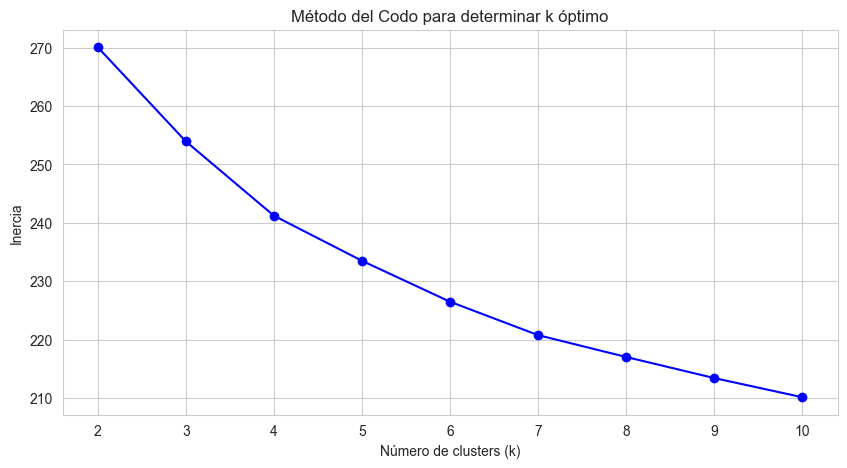


📊 DISTRIBUCIÓN DE CLUSTERS:
Cluster
3    458
2    360
0    351
1    275
Name: count, dtype: int64

🏨 CARACTERÍSTICAS DE CADA CLUSTER:

Cluster 0:
  • Puntuación media: 8.26
  • Reseñas promedio: 1726
  • País predominante: Reino Unido

Cluster 1:
  • Puntuación media: 9.04
  • Reseñas promedio: 961
  • País predominante: España

Cluster 2:
  • Puntuación media: 8.19
  • Reseñas promedio: 1839
  • País predominante: Italia

Cluster 3:
  • Puntuación media: 8.48
  • Reseñas promedio: 832
  • País predominante: Francia


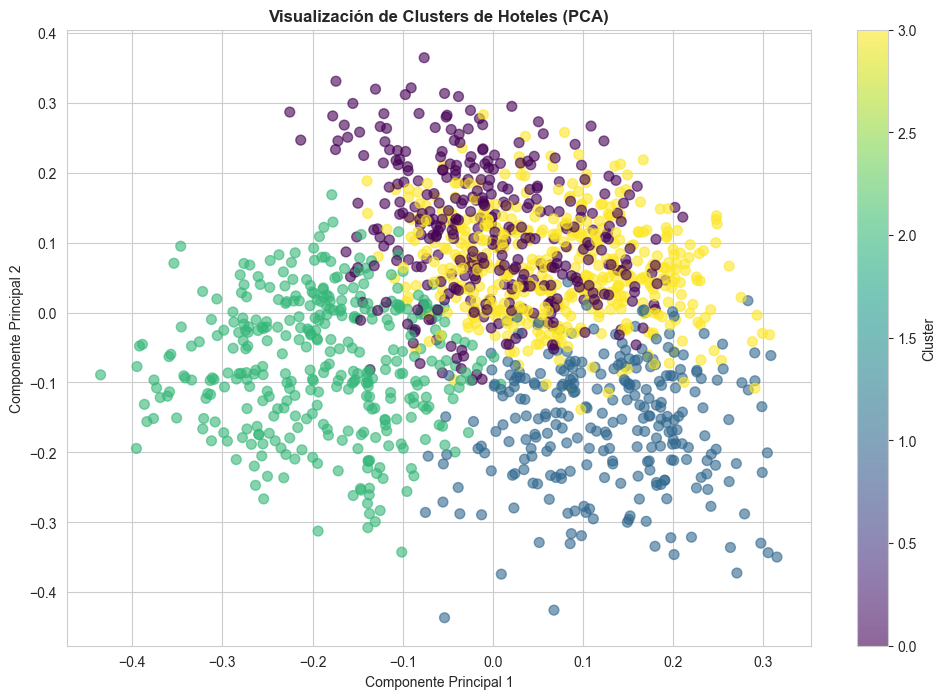

In [23]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("📊 CLUSTERING DE HOTELES BASADO EN OPINIONES")
print("="*80)

# Agregar reseñas por hotel
hotel_reviews = df_limpio.groupby('Hotel_Name').agg({
    'Full_Review': lambda x: ' '.join(x),
    'Reviewer_Score': 'mean',
    'Hotel_Country': 'first',
    'Hotel_City': 'first',
    'Total_Number_of_Reviews': 'first'
}).reset_index()

# Filtrar hoteles con suficientes reseñas
hotel_reviews = hotel_reviews[hotel_reviews['Total_Number_of_Reviews'] >= 100]
print(f"Hoteles con ≥100 reseñas: {len(hotel_reviews)}")

# Vectorizar
vectorizer_cluster = TfidfVectorizer(max_features=500, stop_words='english', min_df=2)
X_hotels = vectorizer_cluster.fit_transform(hotel_reviews['Full_Review'])

# Encontrar número óptimo de clusters (codo)
inercia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_hotels)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inercia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.show()

# Elegir k=4 (parece un buen punto)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
hotel_reviews['Cluster'] = kmeans.fit_predict(X_hotels)

# Analizar clusters
print("\n📊 DISTRIBUCIÓN DE CLUSTERS:")
print(hotel_reviews['Cluster'].value_counts())

# Características de cada cluster
cluster_features = hotel_reviews.groupby('Cluster').agg({
    'Reviewer_Score': 'mean',
    'Total_Number_of_Reviews': 'mean',
    'Hotel_Country': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'mixed'
}).round(2)

print("\n🏨 CARACTERÍSTICAS DE CADA CLUSTER:")
for cluster in range(k_optimo):
    print(f"\nCluster {cluster}:")
    print(f"  • Puntuación media: {cluster_features.loc[cluster, 'Reviewer_Score']}")
    print(f"  • Reseñas promedio: {cluster_features.loc[cluster, 'Total_Number_of_Reviews']:.0f}")
    print(f"  • País predominante: {cluster_features.loc[cluster, 'Hotel_Country']}")

# Visualizar clusters con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hotels.toarray())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hotel_reviews['Cluster'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de Clusters de Hoteles (PCA)', fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

## 8.2) Motor de recomendación sencillo

In [ ]:
print("\n" + "="*80)
print("📊 MOTOR DE RECOMENDACIÓN DE HOTELES")
print("="*80)

def recomendar_hoteles(caracteristica, df, top_n=5):
    """
    Recomienda hoteles basados en una característica especial.
    
    Parámetros:
    - caracteristica: str, ej: "desayuno", "piscina", "vistas", "spa", "wifi"
    - df: DataFrame con reseñas
    - top_n: número de recomendaciones
    """
    
    # Buscar hoteles que mencionan la característica en reseñas positivas
    hoteles_con_caracteristica = df[df['Positive_Review_Clean'].str.contains(
        caracteristica, case=False, na=False
    )]['Hotel_Name'].unique()
    
    if len(hoteles_con_caracteristica) == 0:
        # Buscar también en tags si están disponibles
        if 'Tags_List' in df.columns:
            hoteles_con_caracteristica = df[df['Tags_List'].apply(
                lambda x: any(caracteristica.lower() in str(tag).lower() for tag in x) if isinstance(x, list) else False
            )]['Hotel_Name'].unique()
    
    if len(hoteles_con_caracteristica) == 0:
        print(f"No se encontraron hoteles con '{caracteristica}'")
        return None
    
    # Obtener estadísticas de esos hoteles
    hoteles_recomendados = df[df['Hotel_Name'].isin(hoteles_con_caracteristica)].groupby('Hotel_Name').agg({
        'Reviewer_Score': 'mean',
        'Hotel_City': 'first',
        'Hotel_Country': 'first'
    }).round(2)
    
    # Añadir número de reseñas
    n_resenas = df[df['Hotel_Name'].isin(hoteles_con_caracteristica)].groupby('Hotel_Name').size()
    hoteles_recomendados['N_Reseñas'] = n_resenas
    
    # Filtrar hoteles con suficientes reseñas
    hoteles_recomendados = hoteles_recomendados[hoteles_recomendados['N_Reseñas'] >= 50]
    
    # Ordenar por puntuación
    hoteles_recomendados = hoteles_recomendados.sort_values('Reviewer_Score', ascending=False)
    
    return hoteles_recomendados.head(top_n)

# Ejemplo de uso
print("\n🔍 EJEMPLO: Recomendar hoteles con 'desayuno' incluido")
recomendaciones = recomendar_hoteles('breakfast', df_limpio, top_n=10)
if recomendaciones is not None:
    print(recomendaciones)

print("\n🔍 EJEMPLO: Recomendar hoteles con 'piscina'")
recomendaciones = recomendar_hoteles('pool', df_limpio, top_n=10)
if recomendaciones is not None:
    print(recomendaciones)

# Motor interactivo
print("\n" + "="*80)
print("🎯 MOTOR DE RECOMENDACIÓN INTERACTIVO")
print("="*80)

while True:
    print("\n¿Qué característica buscas en un hotel?")
    print("Ejemplos: desayuno, piscina, spa, wifi, vistas, parking, gym, terraza")
    caracteristica = input("➡️  Escribe una característica (o 'salir'): ").strip().lower()
    
    if caracteristica == 'salir':
        print("¡Hasta luego!")
        break
    
    recomendaciones = recomendar_hoteles(caracteristica, df_limpio, top_n=10)
    
    if recomendaciones is not None:
        print(f"\n🏨 TOP 10 HOTELES CON '{caracteristica}':")
        for idx, (hotel, row) in enumerate(recomendaciones.iterrows(), 1):
            print(f"  {idx}. {hotel[:50]}...")
            print(f"     ⭐ {row['Reviewer_Score']} | 📍 {row['Hotel_City']}, {row['Hotel_Country']} | 📝 {row['N_Reseñas']:.0f} reseñas")
    print("\n" + "-"*50)


📊 MOTOR DE RECOMENDACIÓN DE HOTELES

🔍 EJEMPLO: Recomendar hoteles con 'desayuno' incluido
                                     Reviewer_Score Hotel_City Hotel_Country  \
Hotel_Name                                                                     
Hotel Casa Camper                              9.72  Barcelona        España   
41                                             9.71    Londres   Reino Unido   
H tel de La Tamise Esprit de France            9.69      París       Francia   
Le Narcisse Blanc Spa                          9.67      París       Francia   
H10 Casa Mimosa 4 Sup                          9.66  Barcelona        España   
Hotel The Serras                               9.62  Barcelona        España   
The Soho Hotel                                 9.60    Londres   Reino Unido   
Haymarket Hotel                                9.59    Londres   Reino Unido   
Hotel Sacher Wien                              9.59      Viena       Austria   
Covent Garden Hotel         

# 9) RESUMEN EJECUTIVO

# 📊 Análisis de Reseñas de Hoteles de Lujo en Europa
## Proyecto completo de ETL, EDA, Machine Learning y Recomendación

---

## 📋 Resumen Ejecutivo

Este proyecto analiza **515,738 reseñas** de **1,493 hoteles de lujo** en 6 países europeos (Reino Unido, España, Francia, Países Bajos, Italia, Austria). Se ha realizado un proceso completo de ETL, análisis exploratorio, modelos de regresión, clustering y un motor de recomendación.

### Hallazgos Principales

| Área | Hallazgo | Impacto |
|------|----------|---------|
| **Puntuaciones** | Media global: 8.40 / Mediana: 8.80 | Sesgo positivo (48% son ≥9) |
| **Estacionalidad** | Mejor mes: Febrero (8.53) / Peor: Octubre (8.26) | Planificar promociones en otoño |
| **Correlaciones** | Palabras negativas (-0.383) vs Positivas (+0.221) | **Las quejas importan 1.7x más** |
| **Mejor país** | Austria (8.57) | 147 hoteles, consistencia alta |
| **Peor país** | Reino Unido (8.32) | 400 hoteles, mayor variabilidad |
| **Mejor ciudad** | Viena (8.57) | Menor desviación (1.50) |
| **Peor ciudad** | Londres (8.32) | Mayor desviación (1.67) |

---

## 📈 Análisis por Nacionalidad

### Nacionalidades que puntúan más alto 🏆

| Nacionalidad | Puntuación | Diferencia vs media | Reseñas |
|--------------|------------|---------------------|---------|
| Estados Unidos | 8.79 | +0.39 | 35,108 |
| Israel | 8.70 | +0.30 | 6,527 |
| Nueva Zelanda | 8.66 | +0.26 | 3,218 |
| Australia | 8.59 | +0.19 | 21,502 |
| Canadá | 8.55 | +0.15 | 7,802 |

### Nacionalidades que puntúan más bajo ⚠️

| Nacionalidad | Puntuación | Diferencia vs media | Reseñas |
|--------------|------------|---------------------|---------|
| Irán | 7.73 | -0.67 | 1,070 |
| Pakistán | 7.81 | -0.59 | 911 |
| Jordania | 7.83 | -0.57 | 746 |
| Omán | 7.86 | -0.54 | 1,327 |
| EAU | 7.88 | -0.52 | 10,170 |

**Brecha cultural**: Los estadounidenses puntúan **1.06 puntos más** que los iraníes.

---

## 🔤 Modelo de Regresión: Palabras que predicen puntuación

**Métrica del modelo:** R² = 0.494, RMSE = 1.164

### Palabras que predicen puntuación ALTA 🟢

| Palabra/Frase | Coeficiente | Impacto |
|---------------|-------------|---------|
| excellent | +2.42 | Muy alto |
| reasonably priced | +2.30 | Muy alto |
| perfect | +2.03 | Alto |
| amazing | +2.03 | Alto |
| great | +2.00 | Alto |
| fantastic | +1.88 | Alto |
| high standard | +1.86 | Medio-Alto |
| value money | +1.71 | Medio-Alto |

### Palabras que predicen puntuación BAJA 🔴

| Palabra/Frase | Coeficiente | Impacto |
|---------------|-------------|---------|
| worst | -5.26 | **Extremo** (2x > excellent) |
| dirty | -4.10 | Muy alto |
| rude | -3.93 | Muy alto |
| disgusting | -3.76 | Muy alto |
| filthy | -3.75 | Muy alto |
| horrible | -3.72 | Muy alto |
| unfriendly | -3.53 | Muy alto |
| terrible | -3.48 | Muy alto |

**Conclusión clave:** Las experiencias **negativas extremas tienen el doble de impacto** que las experiencias positivas.

---

## 💬 Análisis de Sentimiento

- **Correlación sentimiento vs puntuación real:** 0.468
- El análisis de sentimiento explica ~22% de la variación en las puntuaciones
- **Métrica utilizada:** TextBlob (50,000 reseñas analizadas)

---

## 🏨 Clustering de Hoteles (4 perfiles)

| Cluster | Puntuación Media | Reseñas Promedio | País Predominante | Perfil |
|---------|------------------|------------------|-------------------|--------|
| **Cluster 1** | 9.04 🏆 | 961 | España | **Excelentes** (top calidad, menor volumen) |
| **Cluster 3** | 8.48 | 832 | Francia | Buenos (estándar alto consistente) |
| **Cluster 0** | 8.26 | 1,726 | Reino Unido | Populares pero críticos (mayor volumen) |
| **Cluster 2** | 8.19 ⚠️ | 1,839 | Italia | Los más exigentes (mayor crítica) |

**Distribución de clusters:** 458 (C3), 360 (C2), 351 (C0), 275 (C1) hoteles

---

## 🎯 Motor de Recomendación

Motor funcional basado en **palabras clave** de reseñas positivas.

### Ejemplo de recomendaciones para "piscina"

| Hotel | Puntuación | Ciudad | País |
|-------|------------|--------|------|
| Hotel Casa Camper | 9.72 | Barcelona | España |
| Le Narcisse Blanc Spa | 9.67 | París | Francia |
| H10 Casa Mimosa 4 Sup | 9.66 | Barcelona | España |
| Hotel The Serras | 9.62 | Barcelona | España |
| Haymarket Hotel | 9.59 | Londres | Reino Unido |

**Características soportadas:** desayuno, piscina, spa, wifi, vistas, parking, gimnasio, terraza

---

## 📊 Estadísticas Finales del Dataset

| Métrica | Valor |
|---------|-------|
| Reseñas totales | 511,944 |
| Hoteles únicos | 1,475 |
| Países | 6 |
| Ciudades | 7 |
| Mejor hotel | Hotel Casa Camper (9.72) |
| Peor hotel | Hotel Liberty (5.12) |

---

## 💡 Recomendaciones de Negocio

1. **Priorizar limpieza y amabilidad del personal**
   - "dirty" y "rude" son las palabras más dañinas (coeficientes > -4.0)

2. **Comunicar "excelente relación calidad-precio"**
   - "reasonably priced" tiene el segundo mayor impacto positivo (+2.30)

3. **Atención diferenciada a viajeros de Oriente Medio**
   - Puntúan sistemáticamente 0.5-0.7 puntos por debajo de la media

4. **Invertir en mejorar estándares para el mercado italiano**
   - El Cluster 2 (Italia) tiene las expectativas más altas (puntuación 8.19)

5. **Prepararse para variaciones estacionales**
   - Las puntuaciones caen en octubre (8.26) y mayo (8.32)
   - Las mejores puntuaciones en febrero (8.53) y diciembre (8.47)

6. **Enfoque en hoteles de alto volumen (Cluster 0 y 2)**
   - Representan el 55% de los hoteles pero tienen las puntuaciones más bajas
   - Mayor oportunidad de mejora y retorno de inversión

---

## 🛠️ Tecnologías Utilizadas

- **Lenguaje:** Python 3.11
- **Librerías principales:** Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, TextBlob
- **Técnicas:** TF-IDF, Regresión Ridge, Clustering K-Means, PCA, Análisis de sentimiento

---

## 📅 Fecha del Análisis

**Datos:** Reseñas de 2015-2017  
**Fecha del informe:** [Fecha actual]

---

*Este análisis fue realizado como parte de un proyecto de ciencia de datos aplicado a reseñas de Booking.com. Los datos son propiedad original de Booking.com y se utilizaron con fines académicos.*